In [1]:
import torch
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3080 Ti'

In [2]:
import os.path
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
import numpy as np
import cv2
import pickle
import albumentations
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

from DeepHeme_training.models.ResNext50 import Myresnext50

In [3]:
train_dir_other = list(Path('D:/Mathijs/Open Universiteit/Thesis/Implementation/Data/bloodcountblastsallcells').glob(r'**/*.jpg'))
train_dir_blasts = list(Path('D:/Mathijs/Open Universiteit/Thesis/Implementation/Data/bloodcountblasts').glob(r'**/*.jpg'))
seg_dir = list(Path('D:/Mathijs/Open Universiteit/Thesis/Implementation/DeepHeme_training/segmentedimages').glob(r'**/*.jpg'))
notext_dir = list(Path('D:/Mathijs/Open Universiteit/Thesis/Implementation/DeepHeme_training/notextimages').glob(r'**/*.jpg'))
#data_filepaths = list(train_dir_other.glob(r'**/*.jpg')) + (list(train_dir_blasts.glob(r'**/*.jpg')))
print(f'total found images: {str(len(train_dir_blasts)+ len(train_dir_other))}')

total found images: 25387


In [12]:
#Extract filepaths and class counts
filepaths = []
filenames = []
finaldiagnosis = []
labels = []
classnames = []

#Extract file path, file name, the final diagnosis of the patient, the cell type, and the classname of the celltypes of the images containing myeloid and lymphoid blasts
for i in range(len(train_dir_blasts)):
    if not (str(train_dir_blasts[i]).split("//")[-1].split("\\")[-1] in filenames): # Avoids duplicate filenames
#        filepaths.append(str(data_filepaths[i]).replace("\\", "/"))
        filepaths.append(str(train_dir_blasts[i]))
        filenames.append(str(train_dir_blasts[i]).split("//")[-1].split("\\")[-1])

        diagnosis = str(train_dir_blasts[i]).split('_')[0].split("\\")[-1].replace(" ", "")
        finaldiagnosis.append(diagnosis)

        classnames.append(str(train_dir_blasts[i]).split("_")[-2])
        #determine blasts through diagnosis, as described by Mathie Leers
        if diagnosis == 'AML' or diagnosis == 'MDS-EB1' or diagnosis == 'MDS-EB2':
            labels.append('Myeloid')
        elif diagnosis == 'B-ALL' or diagnosis == 'T-ALL':
            labels.append('Lymphoid')
        elif diagnosis == 'APL': 
            labels.append('Other')

#Extract the same information from miscelaneous, non-blast, cells
for i in range(len(train_dir_other)):
    if not (str(train_dir_other[i]).split("//")[-1].split("\\")[-1] in filenames): # Avoids duplicate filenames
#        filepaths.append(str(data_filepaths[i]).replace("\\", "/"))
        filepaths.append(str(train_dir_other[i]))
        filenames.append(str(train_dir_other[i]).split("//")[-1].split("\\")[-1])
        finaldiagnosis.append(str(train_dir_other[i]).split('_')[0].split("\\")[-1].replace(" ", ""))
        labels.append('Other')
        classnames.append(str(train_dir_other[i]).split("_")[-2])

print(f"Removed {(len(train_dir_other) + len(train_dir_blasts)) - len(filenames)} duplicates \nTotal images: {len(filenames)}\n")
print(f"Unique labels and their corresponding counts: \n{str(Counter(labels))[7:][1:][:-1]}\n")
print(f"Unique classnames of the celltypes: \n{str(Counter(classnames))[7:][1:][:-1]}\n")
print(f"Unique diagnoses of the patients: \n{str(Counter(finaldiagnosis))[7:][1:][:-1]}")

Removed 4599 duplicates 
Total images: 20788

Unique labels and their corresponding counts: 
{'Other': 11846, 'Myeloid': 7744, 'Lymphoid': 1198}

Unique classnames of the celltypes: 
{'BL': 9004, 'LY': 3963, 'SNE': 2739, 'SMU': 1868, 'MO': 989, 'ART': 550, 'GT': 419, 'ERB': 348, 'PMY': 268, 'ERC': 173, 'MY': 115, 'EO': 77, 'BA': 67, 'RBC': 64, 'MMY': 63, 'BNE': 59, 'PC': 22}

Unique diagnoses of the patients: 
{'AML': 19150, 'B-ALL': 1148, 'MDS-EB1': 348, 'APL': 62, 'T-ALL': 50, 'MDS-EB2': 30}


In [3]:
# # Add filepaths and corresponding labels to a dataframe
# filepath = pd.Series(filepaths, name='Filepath').astype(str)
# labels = pd.Series(labels, name='Label')
# classnames = pd.Series(classnames, name='Classnames')
# diagnosis = pd.Series(finaldiagnosis, name='Final diagnosis')

# # Concatenate filepaths and labels
# df = pd.concat([filepath, labels, diagnosis, classnames], axis=1)

# # Shuffle the DataFrame and reset index
# df = df.sample(frac=1).reset_index(drop=True)

# # Store df in pickle file that can be accessed by other python notebooks
# df.to_pickle("./imagepaths.pkl")

# df.head()

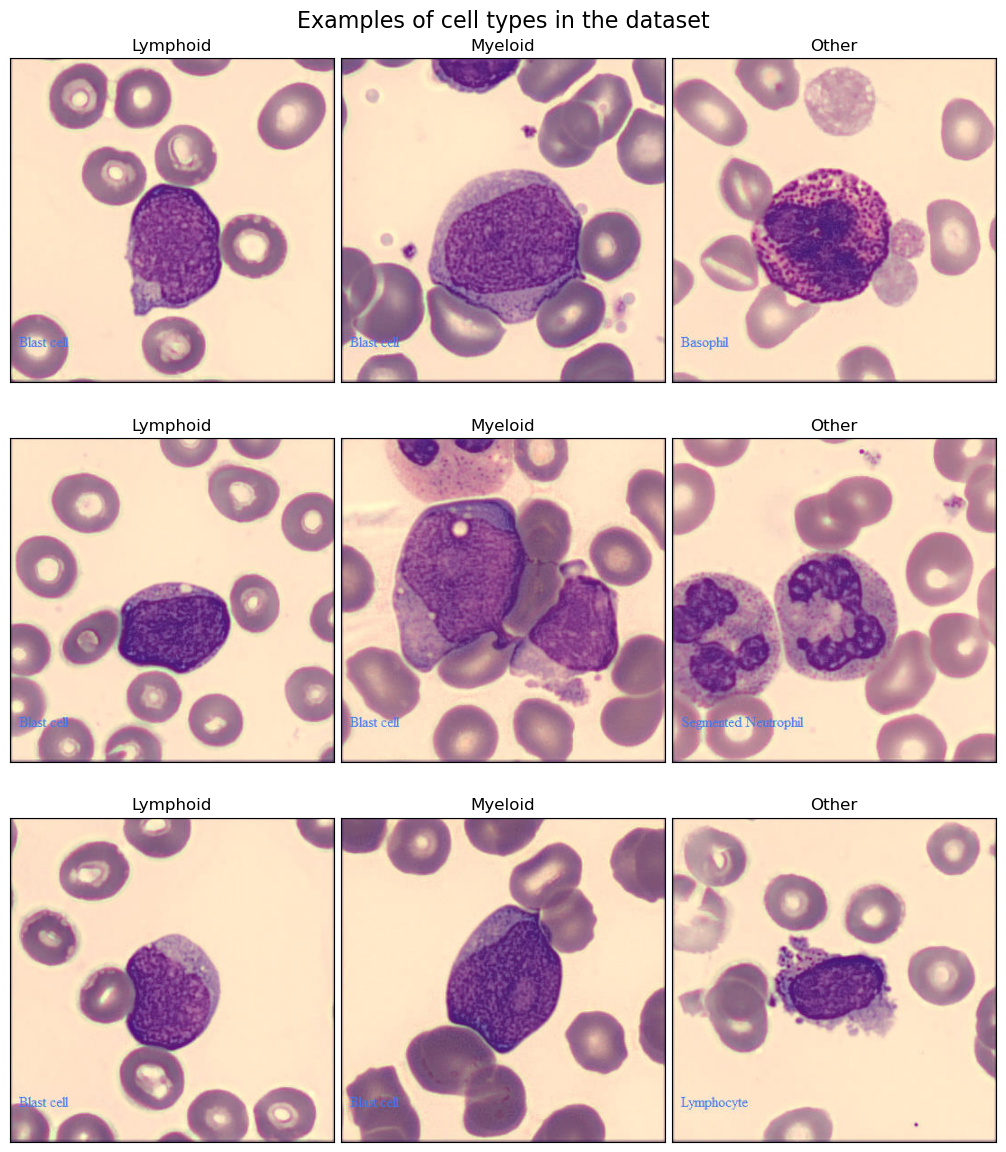

In [3]:
df = pd.read_pickle('imagepaths.pkl')
df_examples = df.groupby("Label", as_index=False).sample(n=3, replace=False).reset_index(drop=True)

# Display some pictures of the dataset

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 12),
                        subplot_kw={'xticks': [], 'yticks': []})
#fig.patch.set_facecolor('#E0E0E0')
fig.patch.set_facecolor('#FFFFFF')
fig.patch.set_alpha(0.7)
plt.suptitle("Examples of cell types in the dataset",size=16)


i = [0,3,6,1,4,7,2,5,8] # To ensure that equivalent cell types are placed below each other
for j, ax in enumerate(axes.flat):
        index = i.pop(0)
        ax.imshow(plt.imread(df_examples.Filepath[index]))
        ax.set_title(df_examples.Label[index], fontsize = 12)
        ax.set_facecolor("white")
plt.tight_layout(pad=0.5)

# Define output directory to save image
out_dir  = "DeepHeme_training/Paperimages"           
out_name = "Example images.pdf"
out_path = os.path.join(out_dir, out_name)


#  Save the current figure as a PDF
plt.savefig(
    out_path,
    format="pdf",        
    dpi=300,              
    bbox_inches="tight"   
)

plt.show()

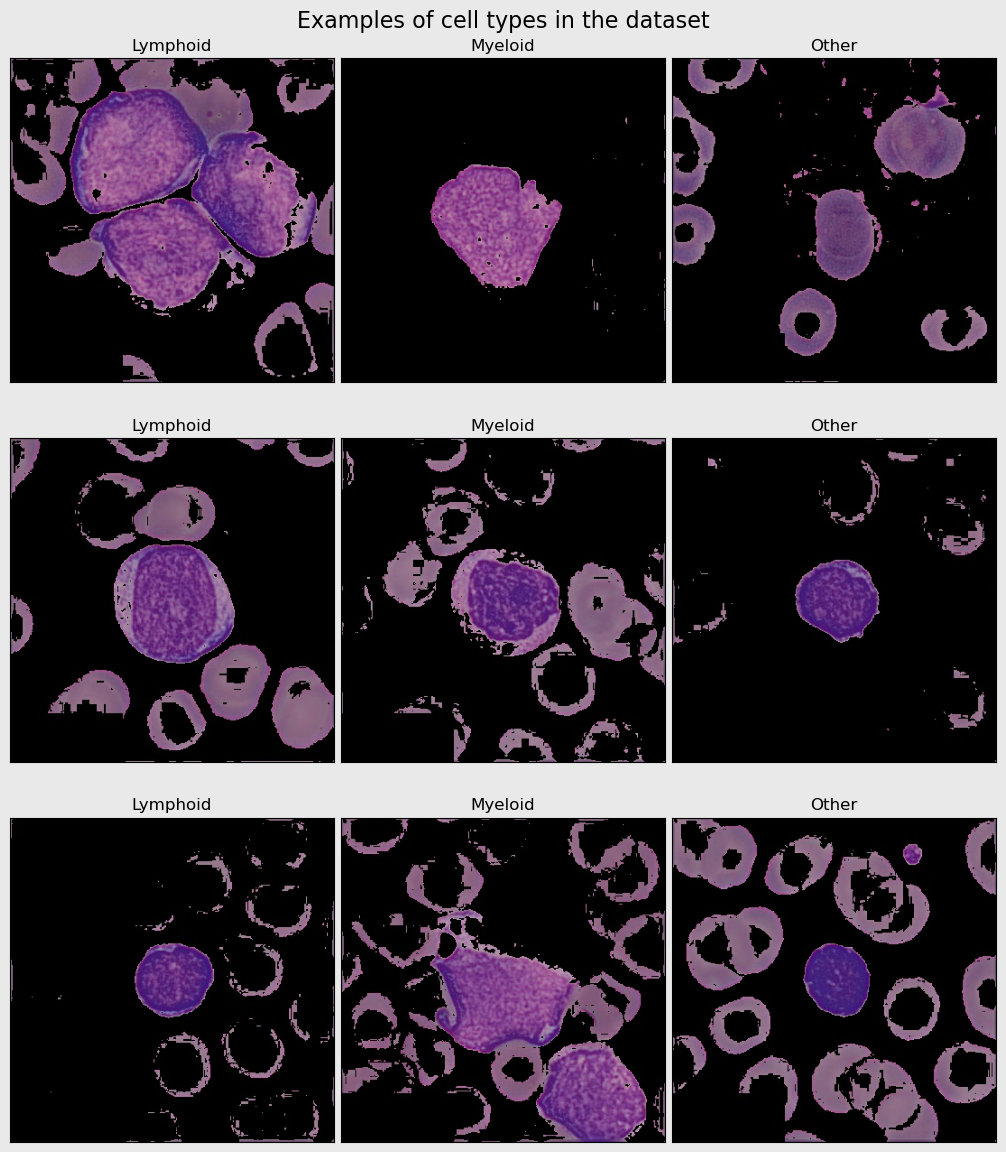

In [18]:
df_examples = seg_df.groupby("Label", as_index=False).sample(n=3, replace=False).reset_index(drop=True)

# Display some pictures of the dataset

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 12),
                        subplot_kw={'xticks': [], 'yticks': []})
fig.patch.set_facecolor('#E0E0E0')
fig.patch.set_alpha(0.7)
plt.suptitle("Examples of cell types in the dataset",size=16)

i = [0,3,6,1,4,7,2,5,8] # To ensure that equivalent cell types are placed below each other
for j, ax in enumerate(axes.flat):
        index = i.pop(0)
        ax.imshow(plt.imread(df_examples.Filepath[index]))
        ax.set_title(df_examples.Label[index], fontsize = 12)
plt.tight_layout(pad=0.5)
plt.show()

In [3]:
import matplotlib.colors as mcolors

def create_median_and_outlier_overlay(df, target_class, image_size=(360, 360)):
    """
    Creates an overlay image that highlights outliers by emphasizing variations.
    
    Parameters:
    - df: Pandas DataFrame with 'filepath' and 'class' columns
    - target_class: The class of images to overlay
    - image_size: (width, height) to resize images
    
    Returns:
    - An enhanced overlay image highlighting outliers
    """
    # Filter images by class
    class_images = df[df['Label'] == target_class]['Filepath'].tolist()

    if not class_images:
        raise ValueError(f"No images found for class: {target_class}")

     # Initialize an empty array for the average overlay
    average_overlay = np.zeros((image_size[1], image_size[0], 3), dtype=np.float32)
    
    # Load images
    image_list = []
    count = 0
    for img_path in class_images:
        if os.path.exists(img_path) and count < 500:
            img = cv2.imread(img_path)
            img = cv2.resize(img, image_size) #should be removed once the wrong images are removed from the pandas dataframe
            img = img.astype(np.float32) / 255.0  # Normalize
            image_list.append(img)
            average_overlay += img
            count+=1

    if not image_list:
        raise ValueError("No valid images found to process.")

    # Compute average overlay by normalizing
    average_overlay /= count
    average_overlay = (average_overlay * 255).astype(np.uint8)  # Convert back to uint8 for visualization
    
    # Convert list to NumPy array
    images = np.stack(image_list, axis=0)  # Shape: (num_images, height, width, channels)

    # Compute median (robust to outliers)
    median_image = np.median(images, axis=0)

    # Compute standard deviation (highlights variation)
    std_dev = np.std(images, axis=0)

    # Normalize standard deviation for visualization (scale 0-255)
    std_dev_norm = (std_dev / np.max(std_dev) * 255).astype(np.uint8)
    
    # Apply color map to highlight variations
    std_dev_colormap = cv2.applyColorMap(std_dev_norm, cv2.COLORMAP_JET)

    # Convert median image back to uint8
    median_overlay = (median_image * 255).astype(np.uint8)

    return average_overlay, median_overlay, std_dev_colormap, std_dev

In [4]:
def plot_with_legend(average_overlay, median_overlay, std_dev_img, std_dev_values, target_class):
    """
    Displays the median overlay and outlier sensitivity heatmap with a color legend.
    
    Parameters:
    - median_img: Composite median image
    - std_dev_img: Outlier sensitivity heatmap
    - std_dev_values: Raw standard deviation values (for color legend scaling)
    - target_class: The class name for labeling
    """
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    # Display Average Overlay
    ax[0].imshow(cv2.cvtColor(average_overlay, cv2.COLOR_BGR2RGB))
    ax[0].axis("off")
    ax[0].set_title(f"Average Overlay of {target_class}")
    
    # Display Median Overlay
    ax[1].imshow(cv2.cvtColor(median_overlay, cv2.COLOR_BGR2RGB))
    ax[1].axis("off")
    ax[1].set_title(f"Median Overlay of {target_class}")

    # Display Standard Deviation Heatmap
    ax[2].imshow(cv2.cvtColor(std_dev_img, cv2.COLOR_BGR2RGB))
    ax[2].axis("off")
    ax[2].set_title(f"Outlier Sensitivity Map of {target_class}")

    # Create a colorbar legend
    norm = mcolors.Normalize(vmin=np.min(std_dev_values), vmax=np.max(std_dev_values))
    sm = plt.cm.ScalarMappable(cmap="jet", norm=norm)
    sm.set_array([])  # Empty array for colorbar
    cbar = plt.colorbar(sm, ax=ax[2], fraction=0.046, pad=0.04)
    cbar.set_label("Standard Deviation (Outlier Sensitivity)")

    plt.show()

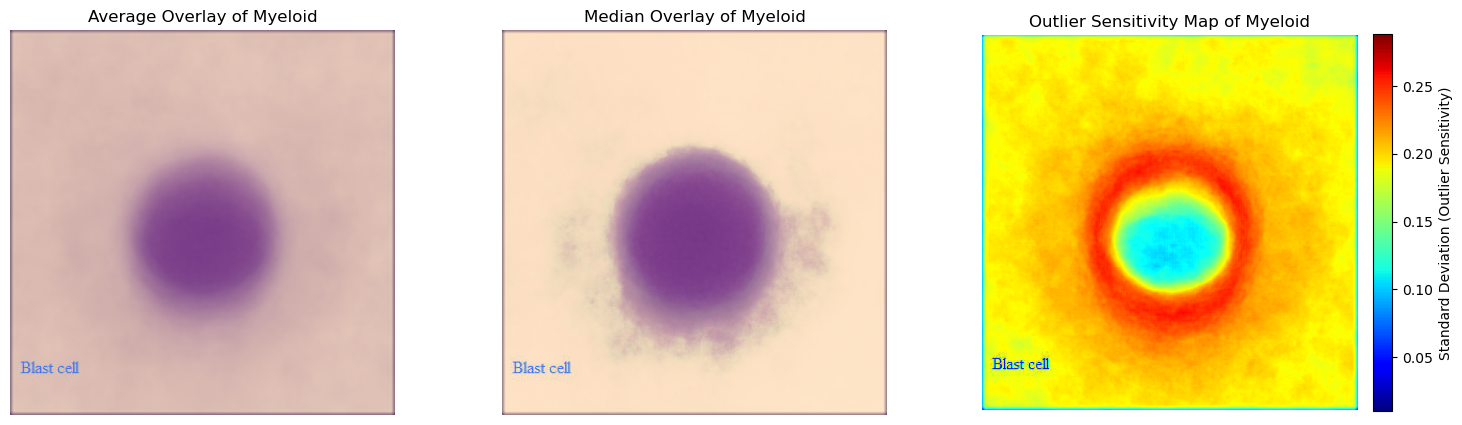

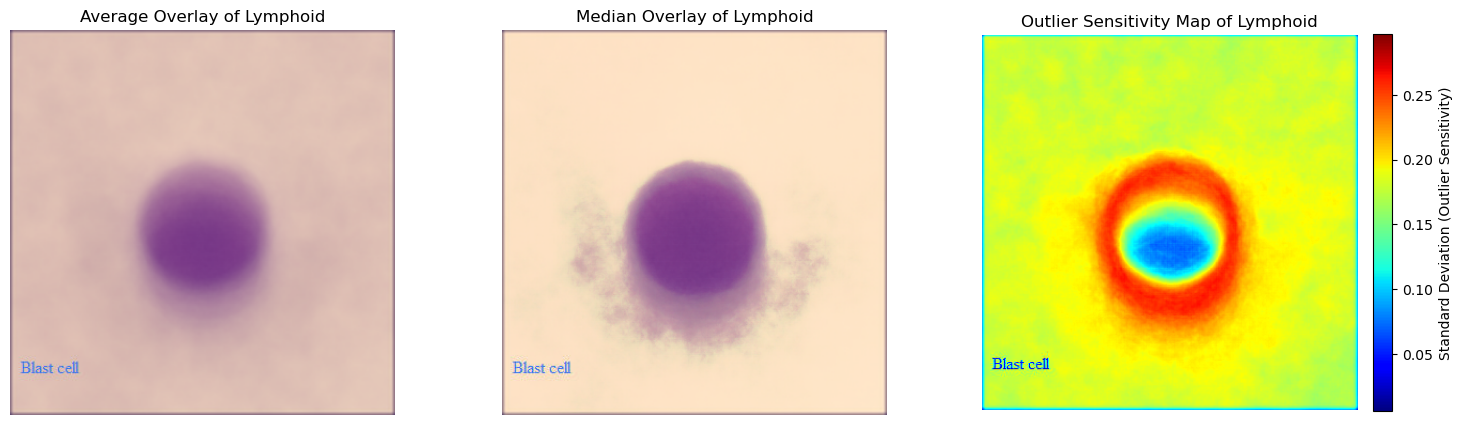

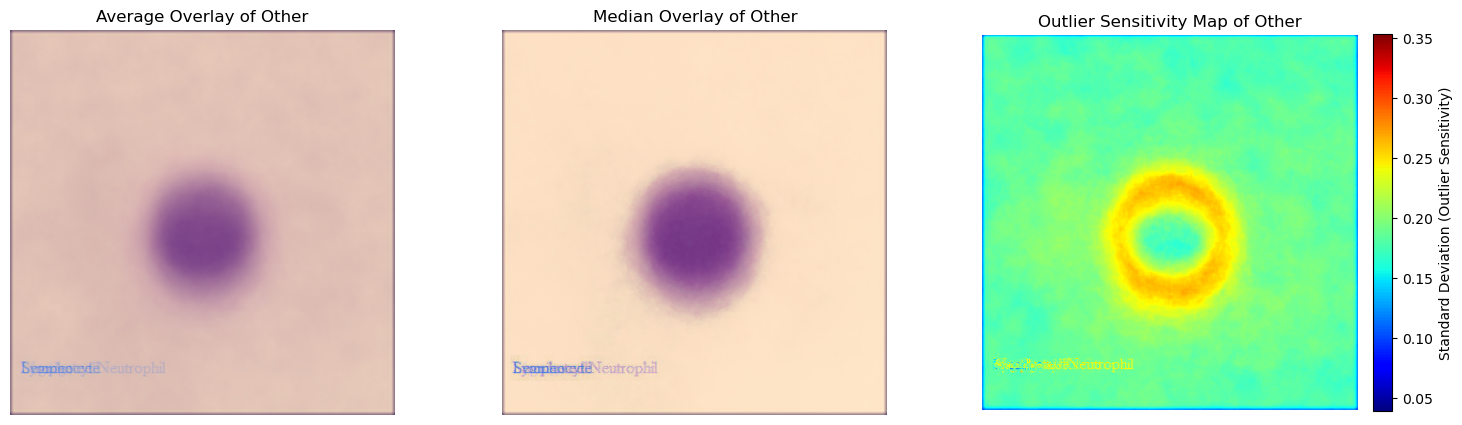

In [5]:
df = pd.read_pickle('imagepaths.pkl')
celltypes = ["Myeloid", "Lymphoid", "Other"]
for celltype in celltypes:
    average_overlay, median_overlay, std_dev_img, std_dev_values = create_median_and_outlier_overlay(df, celltype)
    plot_with_legend(average_overlay, median_overlay, std_dev_img, std_dev_values, celltype)


In [9]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def create_sensitive_overlay(df, target_class, image_size=(256, 256)):
    """
    Creates median and std dev maps for a specific class.
    
    Returns:
    - median_image_uint8: median composite image
    - std_dev: raw standard deviation values (for later normalization)
    """
    class_images = df[df['Label'] == target_class]['Filepath'].tolist()

    image_list = []
    for img_path in class_images:
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            img = cv2.resize(img, image_size)
            img = img.astype(np.float32) / 255.0
            image_list.append(img)

    if not image_list:
        raise ValueError(f"No valid images found for class {target_class}.")

    images = np.stack(image_list, axis=0)
    median_image = np.median(images, axis=0)
    std_dev = np.std(images, axis=0)

    median_image_uint8 = (median_image * 255).astype(np.uint8)

    return median_image_uint8, std_dev

def generate_std_dev_colormap(std_dev, global_min, global_max):
    """
    Apply consistent normalization and colormap to std_dev image.
    """
    std_norm = ((std_dev - global_min) / (global_max - global_min + 1e-8))  # Normalize to [0,1]
    std_norm = np.clip(std_norm, 0, 1)  # Just in case
    std_uint8 = (std_norm * 255).astype(np.uint8)
    std_colormap = cv2.applyColorMap(std_uint8, cv2.COLORMAP_JET)
    return std_colormap

def plot_with_shared_legend(results, global_min, global_max):
    """
    Display each class's overlay and outlier map with a shared colorbar.
    `results` is a list of (class_name, median_img, std_dev_colormap).
    """
    n = len(results)
    fig, axes = plt.subplots(n, 2, figsize=(10, 5 * n))

    if n == 1:
        axes = [axes]  # Make iterable

    for i, (class_name, median_img, std_dev_img) in enumerate(results):
        ax_overlay = axes[i][0]
        ax_heatmap = axes[i][1]

        ax_overlay.imshow(cv2.cvtColor(median_img, cv2.COLOR_BGR2RGB))
        ax_overlay.axis("off")
        ax_overlay.set_title(f"Median Overlay: {class_name}")

        ax_heatmap.imshow(cv2.cvtColor(std_dev_img, cv2.COLOR_BGR2RGB))
        ax_heatmap.axis("off")
        ax_heatmap.set_title(f"Outlier Sensitivity Map: {class_name}")

    # Shared colorbar
    norm = mcolors.Normalize(vmin=global_min, vmax=global_max)
    sm = plt.cm.ScalarMappable(cmap="jet", norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.04)
    cbar.set_label("Standard Deviation (Outlier Sensitivity)")

    plt.tight_layout()
    plt.show()


C:\Users\moone\AppData\Local\Temp\ipykernel_25812\167266674.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


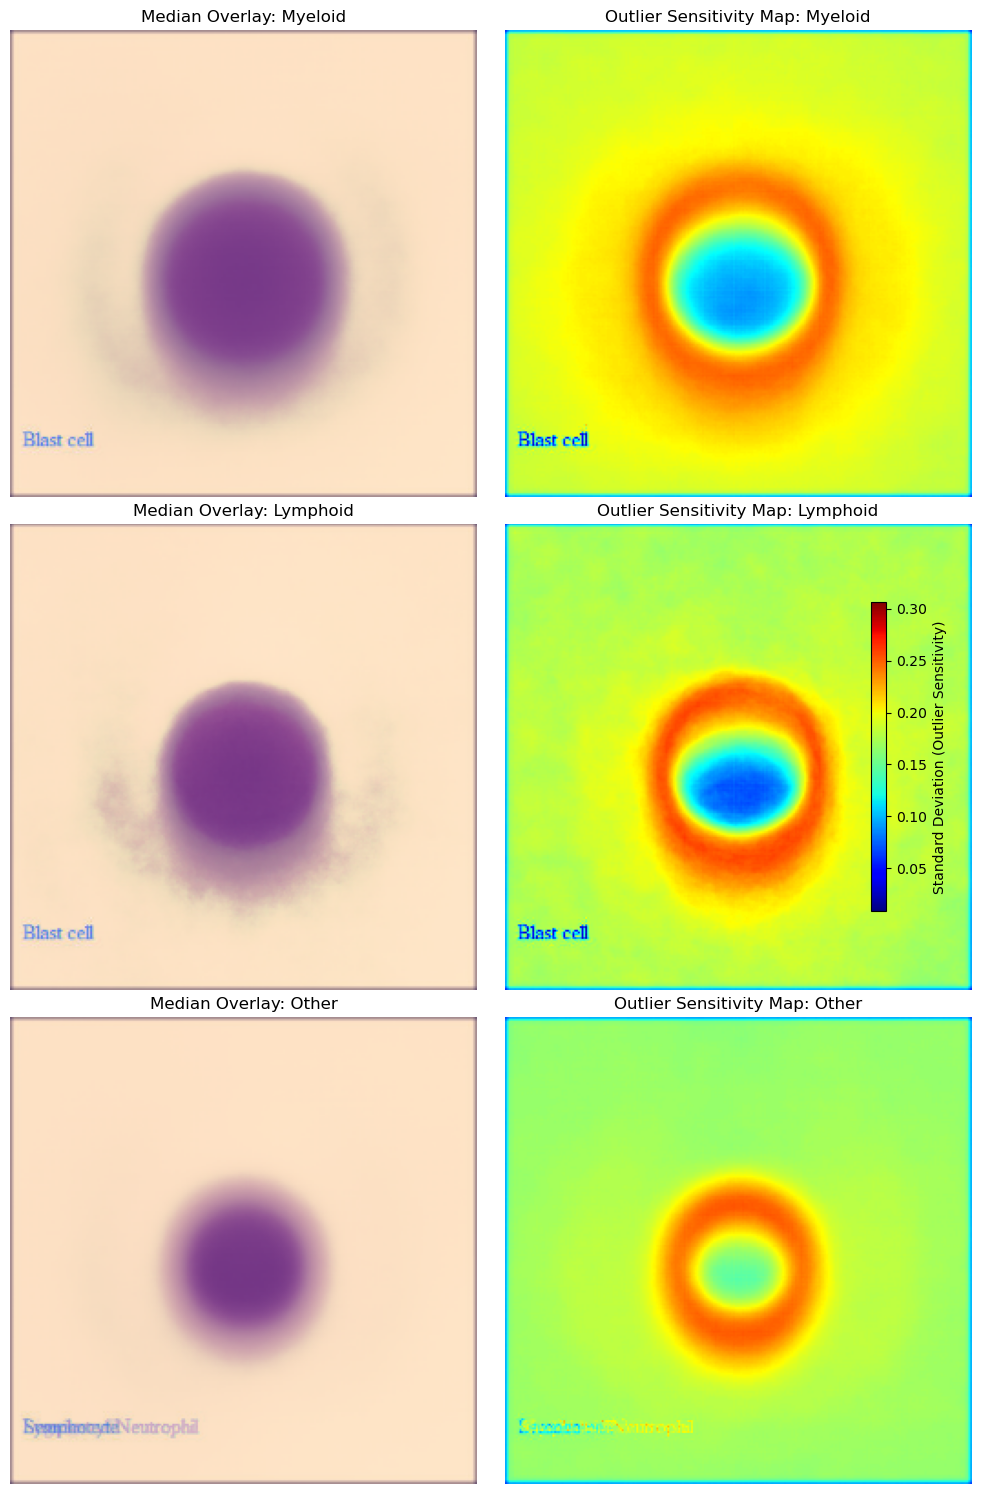

In [10]:
df = pd.read_pickle('imagepaths.pkl')

classes = ["Myeloid", "Lymphoid", "Other"]
results = []
all_std_devs = []

# Step 1: Collect all std dev maps and compute global min/max
for cls in classes:
    median_img, std_dev = create_sensitive_overlay(df, cls)
    all_std_devs.append(std_dev)
    results.append((cls, median_img, std_dev))  # Temporarily save std_dev (raw)

# Compute global range for normalization
global_min = np.min([np.min(std) for std in all_std_devs])
global_max = np.max([np.max(std) for std in all_std_devs])

# Step 2: Generate colormaps using global bounds
final_results = []
for cls, median_img, std_dev in results:
    std_dev_colormap = generate_std_dev_colormap(std_dev, global_min, global_max)
    final_results.append((cls, median_img, std_dev_colormap))

# Step 3: Plot with shared legend
plot_with_shared_legend(final_results, global_min, global_max)


In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import cv2
import numpy as np

def plot_with_shared_legends_per_map(results, global_min, global_max):
    """
    Plots each class with median overlay and std dev heatmap.
    Each heatmap gets its own legend, using shared global color range.
    
    `results` is a list of (class_name, median_img, std_dev_colormap, std_dev_gray)
    """
    n = len(results)
    fig = plt.figure(figsize=(12, 5 * n))
    gs = gridspec.GridSpec(n, 3, width_ratios=[1, 1, 0.05], wspace=0.3)

    for i, (class_name, median_img, std_dev_colormap, std_dev_gray) in enumerate(results):
        # Median overlay
        ax1 = fig.add_subplot(gs[i, 0])
        ax1.imshow(cv2.cvtColor(median_img, cv2.COLOR_BGR2RGB))
        ax1.axis("off")
        ax1.set_title(f"Median Overlay: {class_name}")

        # Heatmap
        ax2 = fig.add_subplot(gs[i, 1])
        im = ax2.imshow(cv2.cvtColor(std_dev_colormap, cv2.COLOR_BGR2RGB))
        ax2.axis("off")
        ax2.set_title(f"Outlier Sensitivity Map: {class_name}")

        # Colorbar
        ax3 = fig.add_subplot(gs[i, 2])
        norm = mcolors.Normalize(vmin=global_min, vmax=global_max)
        sm = plt.cm.ScalarMappable(cmap="jet", norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, cax=ax3)
        cbar.set_label("Standard Deviation (Outlier Sensitivity)")

    plt.tight_layout()
    plt.show()


C:\Users\moone\AppData\Local\Temp\ipykernel_25812\2821567922.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


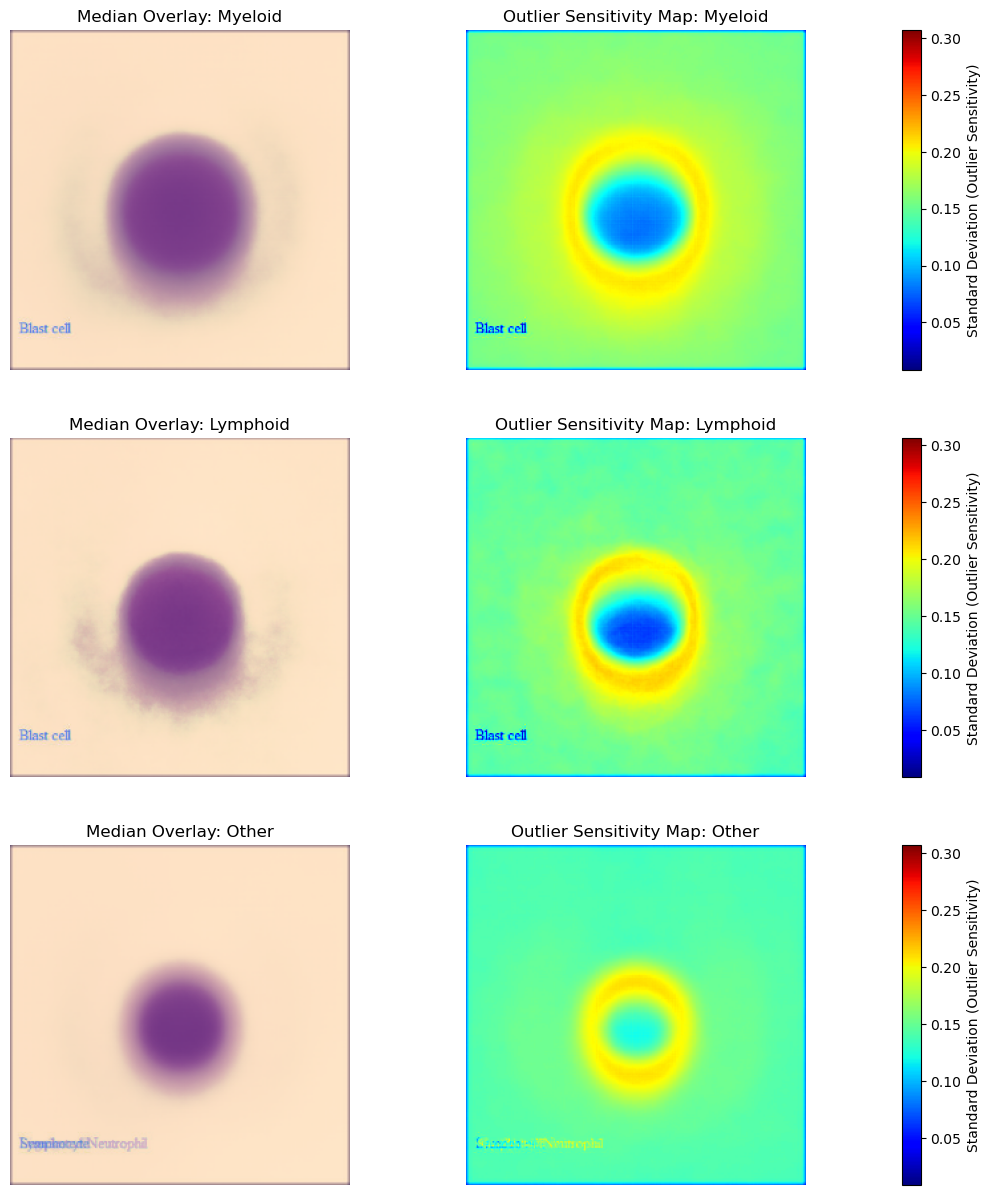

In [12]:
df = pd.read_pickle('imagepaths.pkl')

classes = ["Myeloid", "Lymphoid", "Other"]
final_results = []

for cls in classes:
    median_img, std_dev = create_sensitive_overlay(df, cls)

    std_gray = np.mean(std_dev, axis=2)
    std_norm = ((std_gray - global_min) / (global_max - global_min + 1e-8)) * 255
    std_norm = np.clip(std_norm, 0, 255).astype(np.uint8)
    std_dev_colormap = cv2.applyColorMap(std_norm, cv2.COLORMAP_JET)

    final_results.append((cls, median_img, std_dev_colormap, std_gray))

plot_with_shared_legends_per_map(final_results, global_min, global_max)


## Image transformation pipeline visualized

In [3]:
# Define transform pipeline
transform_pipeline = albumentations.Compose(
    [
        albumentations.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        
    ]
)

# Load the data and extract an image
df = pd.read_pickle('imagepaths.pkl')
notextdf = pd.read_pickle('croppedimagepaths.pkl')
imgpath = df['Filepath'][0]
notextimgpath = notextdf['Filepath'][0]
print(imgpath)
print(notextimgpath)

img0 = cv2.imread(imgpath)
img1 = cv2.imread(notextimgpath)
img2 = cv2.resize(img1, (256,256))
img3 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img4 = transform_pipeline(image=img3)["image"]
#img5 = np.einsum('ijk->kij', img4), commented out because this doesn't actually transform the image, but rather reorders the axes in the way that Pytorch expects it

images = [img0, img1, img2, img3, img4]

D:\Mathijs\Open Universiteit\Thesis\Implementation\Data\bloodcountblastsallcells\AML___210801000818_1_SMU_13.jpg
D:\Mathijs\Open Universiteit\Thesis\Implementation\DeepHeme_training\Datasets\croppedimages\AML___210801000818_1_SMU_13.jpg


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


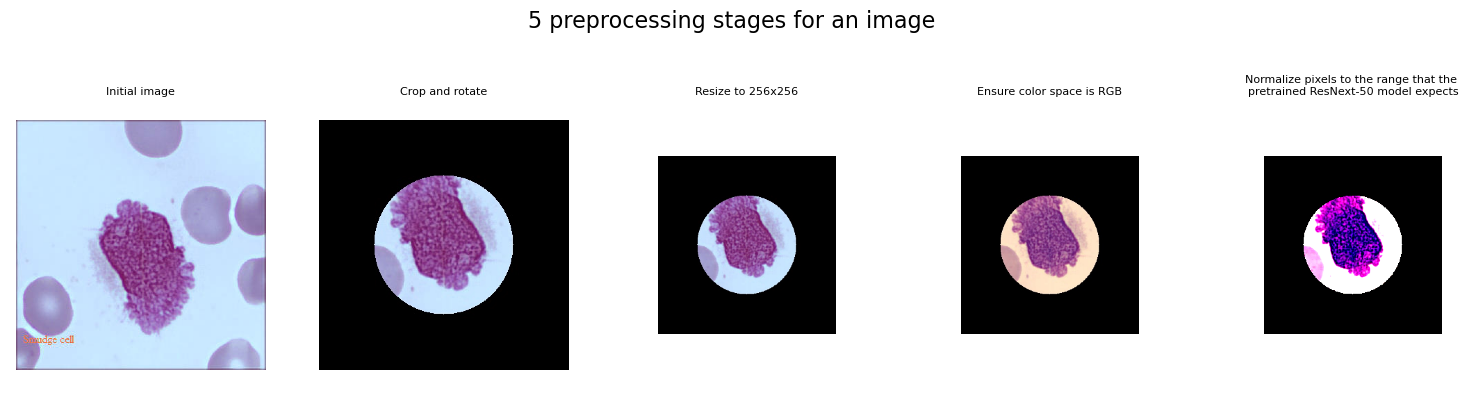

In [4]:
titles = ['Initial image','Crop and rotate','Resize to 256x256','Ensure color space is RGB',
          'Normalize pixels to the range that the \npretrained ResNext-50 model expects']

rows, cols = 1, 5
fig, axes = plt.subplots(rows, cols, figsize=(15, 4))
fig.suptitle('5 preprocessing stages for an image', fontsize=16)

for i, ax in enumerate(axes.flat):
    title = titles[i]

    # Choose zoom level depending on resolution
    if i < 1:
        zoom = 0.5  # larger display
    else:
        zoom = 0.5  # make lower-res images smaller visually

    # Create and add image box
    imagebox = OffsetImage(images[i], cmap='coolwarm', zoom=zoom)
    ab = AnnotationBbox(imagebox, (0.5, 0.5), frameon=False)
    ax.add_artist(ab)

    ax.set_title(title, fontsize=8)
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Display results for final paper

In [15]:
results = pd.read_excel('Results/Training results.xlsx')
results

,Model name,train-test-split,train-test-split random state,"Results (AUC, F1, ACC, Precision, Recall)",Description,Dataframe
0,checkpoint_best_2025422.ckpt,85/15,42.0,"{'Lymphoid': [0.9962326566103361, 0.8921282798...","Initial evaluation of results, results evaluat...",imagepaths.pkl
1,checkpoint_best_2025423.ckpt,80/10/10,42.0,"{'Lymphoid': [0.9967330270546197, 0.8776371308...","No changes to data preprocessing or model, onl...",imagepaths.pkl
2,checkpoint_best_202542310.ckpt,2010-10-01 00:00:00,42.0,"{'Lymphoid': [0.9954781351029438, 0.9075630252...",Re-trained the same model as in the previous s...,imagepaths.pkl
3,checkpoint_best_202542315.ckpt,2010-10-01 00:00:00,42.0,"{'Lymphoid': [0.5528075548749363, 0.0, 0.94227...","Model trained on <100 images, to verify whethe...",imagepaths.pkl
4,checkpoint_best_202542316.ckpt,80/10/10,42.0,"{'Lymphoid': [0.9947337076739833, 0.8849557522...","Deleted the checkpoints before training, ensur...",imagepaths.pkl
5,checkpoint_best_20255113,NaN,NaN,"{'Lymphoid': [0.9499829845159096, 0.5586592178...","First attempt with segmented images, in which ...",segmentedimagepaths.pkl
6,checkpoint_best_2025569.ckpt,80/10/10,42.0,"{'Lymphoid': [0.955423685553854, 0.63348416289...",Using the segmented images with all blue text ...,segmentedimagepaths.pkl
7,checkpoint_best_20255612.ckpt,80/10/10,42.0,"{'Lymphoid': [0.9918836140888208, 0.8340080971...","Trained using the notextimagepaths.pkl, where ...",notextimagepaths.pkl
8,checkpoint_best_20255810.ckpt,80/10/10,42.0,"{'Lymphoid': [0.987491, 0.808163, 0.977338, 0....",Through euclidean distance = 0.0 removed addit...,notextimagepaths.pkl
9,checkpoint_best_20256213.ckpt,80/10/10,42.0,"{'Lymphoid': [0.9785481099656358, 0.5964912280...","Using EUCD < 1.0, and a nearest neighbour algo...",notextimagepaths.pkl


In [16]:
# Extract results from the results excel file that was used to manually keep track of results
metrics = results['Results (AUC, F1, ACC, Precision, Recall)'].to_list()

#Initialize list of lists to store final results, each inner list will become a column in the dataframe:
class_results = []
for i in range(15):
    class_results.append([])

for i in range(len(metrics)):
    #Extract results corresponding to a single row in the final dataframe
    class_results_messy = metrics[i]

    #Store the values in a list to be converted to a column in our dataframe
    class_results_clean = class_results_messy.replace("{'Lymphoid': [", '').replace(']', '').replace(' ', '').replace('[', '').replace("'Myeloid':", '').replace("'Other':", '').replace('}','').split(',')
    for j in range(15):
        class_results[j].append(float(class_results_clean[j]))

# Add the columns to a dataframe
new_cols = pd.DataFrame(class_results).T

# Name the columns:
col_headers = ['Lymphoid AUC', 'Lymphoid F1', 'Lymphoid Accuracy', 'Lymphoid Precision', 'Lymphoid Recall', 'Myeloid AUC', 'Myeloid F1', 'Myeloid Accuracy', 'Myeloid Precision', 'Myeloid Recall', 'Other AUC', 'Other F1', 'Other Accuracy', 'Other Precision', 'Other Recall']
new_cols.columns = [col_headers[i] for i in range(len(col_headers))]

# Add the columns to the original dataframe and remove the column that originally contained all results
results = pd.concat([results,new_cols], axis=1).drop('Results (AUC, F1, ACC, Precision, Recall)', axis=1)
results.head()

,Model name,train-test-split,train-test-split random state,Description,Dataframe,Lymphoid AUC,Lymphoid F1,Lymphoid Accuracy,Lymphoid Precision,Lymphoid Recall,Myeloid AUC,Myeloid F1,Myeloid Accuracy,Myeloid Precision,Myeloid Recall,Other AUC,Other F1,Other Accuracy,Other Precision,Other Recall
0,checkpoint_best_2025422.ckpt,85/15,42.0,"Initial evaluation of results, results evaluat...",imagepaths.pkl,0.996233,0.892128,0.988137,0.938650,0.850000,0.998613,0.982516,0.986855,0.973795,0.991394,0.999401,0.998873,0.998718,1.000000,0.997749
1,checkpoint_best_2025423.ckpt,80/10/10,42.0,"No changes to data preprocessing or model, onl...",imagepaths.pkl,0.996733,0.877637,0.986051,0.888889,0.866667,0.998645,0.978177,0.983646,0.973180,0.983226,0.999625,0.997038,0.996633,0.999152,0.994932
2,checkpoint_best_202542310.ckpt,2010-10-01 00:00:00,42.0,Re-trained the same model as in the previous s...,imagepaths.pkl,0.995478,0.907563,0.989418,0.915254,0.900000,0.998188,0.982659,0.987013,0.978261,0.987097,0.999484,0.997884,0.997595,1.000000,0.995777
3,checkpoint_best_202542315.ckpt,2010-10-01 00:00:00,42.0,"Model trained on <100 images, to verify whethe...",imagepaths.pkl,0.552808,0.000000,0.942280,0.000000,0.000000,0.767628,0.549840,0.389610,0.379159,1.000000,0.769052,0.057424,0.447330,1.000000,0.029561
4,checkpoint_best_202542316.ckpt,80/10/10,42.0,"Deleted the checkpoints before training, ensur...",imagepaths.pkl,0.994734,0.884956,0.987494,0.943396,0.833333,0.998271,0.980242,0.985089,0.968514,0.992258,0.999308,0.997884,0.997595,1.000000,0.995777


In [17]:
Dataset = results['Dataframe'].to_list()
Dataset

['imagepaths.pkl',
 'imagepaths.pkl',
 'imagepaths.pkl',
 'imagepaths.pkl',
 'imagepaths.pkl',
 'segmentedimagepaths.pkl',
 'segmentedimagepaths.pkl',
 'notextimagepaths.pkl',
 'notextimagepaths.pkl',
 'notextimagepaths.pkl',
 'croppedimagepaths.pkl',
 'croppedimagepaths.pkl',
 'croppedimagepaths.pkl',
 'croppedimagepaths.pkl',
 'croppedimagepaths.pkl']

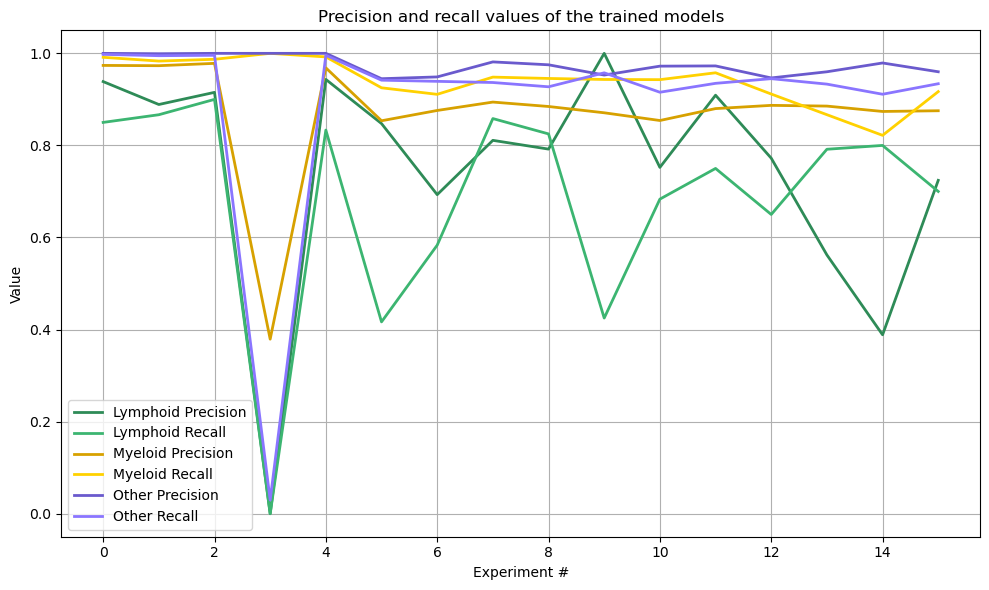

In [13]:
# Plot results

# The columns to plot
selected_cols = ['Lymphoid Precision', 'Lymphoid Recall', 'Myeloid Precision', 'Myeloid Recall', 'Other Precision', 'Other Recall']

# Define base hexcodes for the 3 groups
base_colors = ['#2E8B57','#D7A100','#6A5ACD']

# Helper to lighten/darken a hex color
def adjust_color(hex_color, factor=1.2):
    rgb = mcolors.hex2color(hex_color)
    adjusted_rgb = tuple(min(1, c * factor) for c in rgb)
    return adjusted_rgb
    
# Create pairs of (base, lighter) shades for each group
color_pairs = []
for base in base_colors:
    color_pairs.append([base, adjust_color(base, factor=1.3)])


# Flatten the list to match 6 lines
flat_colors = [color for pair in color_pairs for color in pair]

# Plot
plt.figure(figsize=(10, 6))

for i, col in enumerate(selected_cols):
    plt.plot(results.index, results[col], label=col, color=flat_colors[i], linewidth=2)

plt.legend()
plt.title("Precision and recall values of the trained models")
plt.xlabel("Experiment #")
plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()

#Optional, save the figure
plt.savefig('PrecisionRecallplotALL.png', dpi=500, bbox_inches='tight')

plt.show()

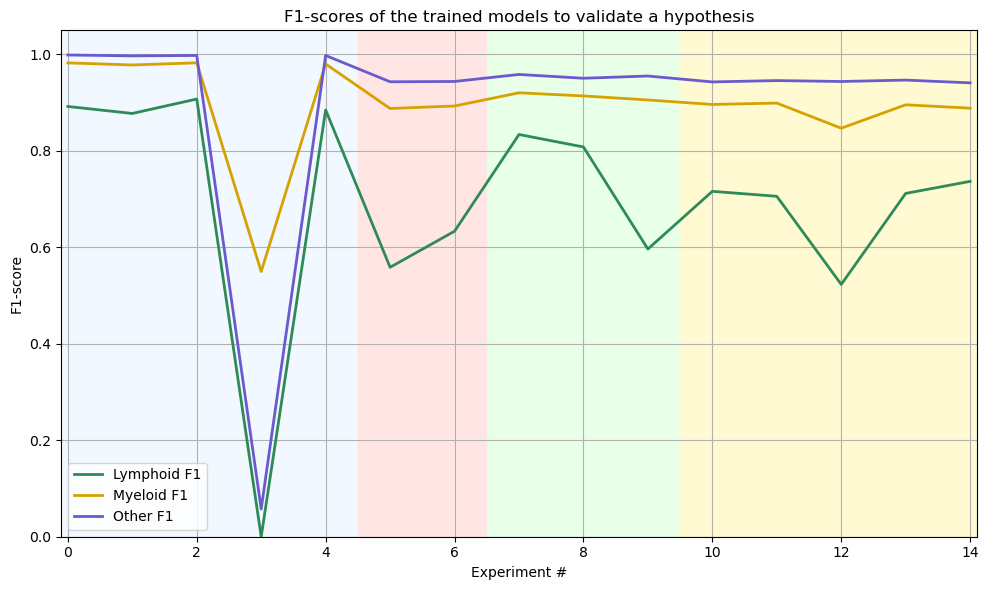

In [18]:
# Plot results

# The columns to plot
selected_cols = ['Lymphoid F1',  'Myeloid F1', 'Other F1']

# Define base hexcodes for the 3 groups
base_colors = ['#2E8B57','#D7A100','#6A5ACD']


##865C70

# Plot
plt.figure(figsize=(10, 6))

dataset_colors = {
    'imagepaths.pkl': '#f0f8ff',   # light blue
    'segmentedimagepaths.pkl': '#ffe4e1',    # light pink
    'notextimagepaths.pkl': '#e6ffe6',  # light green
    'croppedimagepaths.pkl': '#fffacd'    # light yellow
}

# Shade background based on Dataset list
prev_dataset = Dataset[0]
start_idx = 0

for i in range(1, len(Dataset) + 1):
    if i == len(Dataset) or Dataset[i] != prev_dataset:
        plt.axvspan(start_idx - 0.5, i - 0.5, color=dataset_colors[prev_dataset], alpha=0.9)
        if i < len(Dataset):
            prev_dataset = Dataset[i]
            start_idx = i

for i, col in enumerate(selected_cols):
    plt.plot(results.index, results[col], label=col, color=base_colors[i], linewidth=2)

plt.legend()
plt.title("F1-scores of the trained models to validate a hypothesis")
plt.xlim(-0.1, len(results.index) - 1 + 0.1)  # or just (0, 15) if your index is 0-15
plt.ylim(0.0, 1.05)  # Assuming precision/recall values are between 0 and 1
plt.xlabel("Experiment #")
plt.ylabel("F1-score")
plt.grid(True)
plt.tight_layout()

# Define output directory to save image
out_dir  = "DeepHeme_training/Paperimages/Final images"           
out_name = "All experiments - F1 scores.pdf"
out_path = os.path.join(out_dir, out_name)


#  Save the current figure as a PDF
plt.savefig(
    out_path,
    format="pdf",        
    dpi=300,              
    bbox_inches="tight"   
)

plt.show()

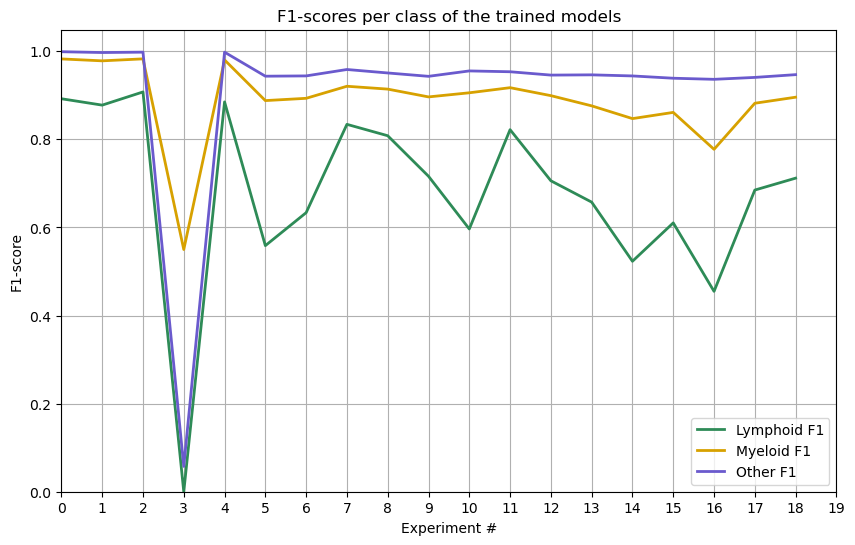

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# The columns to plot
selected_cols = ['Lymphoid F1', 'Myeloid F1', 'Other F1']

# Define base hexcodes for the 3 groups
base_colors = ['#2E8B57', '#D7A100', '#6A5ACD']

# Plot
plt.figure(figsize=(10, 6))

for i, col in enumerate(selected_cols):
    plt.plot(results.index, results[col], label=col, color=base_colors[i], linewidth=2)

# Fix axes: set bottom-left to (0, 0), and show only integer x-ticks
plt.xlim(left=0)
plt.ylim(bottom=0)

# Force integer x-ticks only
plt.xticks(np.arange(0, len(results.index) + 1, 1))  # +1 ensures last index is included

plt.legend()
plt.title("F1-scores per class of the trained models")
plt.xlabel("Experiment #")
plt.ylabel("F1-score")
plt.grid(True)
plt.show()

# Final model across epochs

In [29]:
results = pd.read_excel('Results/Training results.xlsx')
#results = results.drop(8).reset_index(drop=True)
results

model_epochs = ["{'Lymphoid': [0.9657431271477664, 0.6102719033232629, 0.9373786407766991, 0.4786729857819905, 0.8416666666666667], 'Myeloid': [0.963032314806934, 0.8611295681063122, 0.8985436893203883, 0.8674698795180723, 0.8548812664907651], 'Other': [0.9758863977120744, 0.9387040280210157, 0.9320388349514563, 0.9727767695099818, 0.9069373942470389]}", "{'Lymphoid': [0.9640120274914089, 0.45491803278688525, 0.870873786407767, 0.3016304347826087, 0.925], 'Myeloid': [0.9468546461907599, 0.777292576419214, 0.8514563106796117, 0.8668831168831169, 0.7044854881266491], 'Other': [0.9750548277310762, 0.9362267493356953, 0.9300970873786408, 0.9823420074349443, 0.8942470389170897]}", "{'Lymphoid': [0.9647465635738832, 0.6848249027237354, 0.9606796116504854, 0.6423357664233577, 0.7333333333333333], 'Myeloid': [0.9659545493233467, 0.8819095477386935, 0.9087378640776699, 0.841726618705036, 0.9261213720316622], 'Other': [0.9799604161126079, 0.940554821664465, 0.9344660194174758, 0.9807162534435262, 0.9035532994923858]}", "{'Lymphoid': [0.9566022336769759, 0.711864406779661, 0.9669902912621359, 0.7241379310344828, 0.7], 'Myeloid': [0.9692628349322537, 0.895618556701031, 0.9213592233009709, 0.8753148614609572, 0.91688654353562], 'Other': [0.980130006282545, 0.9468267581475128, 0.9398058252427185, 0.96, 0.934010152284264]}" ]

#Initialize list of lists to store final results, each inner list will become a column in the dataframe:
class_results = []
for i in range(15):
    class_results.append([])

for i in range(len(model_epochs)):
    #Extract results corresponding to a single row in the final dataframe
    class_results_messy = model_epochs[i]

    #Store the values in a list to be converted to a column in our dataframe
    class_results_clean = class_results_messy.replace("{'Lymphoid': [", '').replace(']', '').replace(' ', '').replace('[', '').replace("'Myeloid':", '').replace("'Other':", '').replace('}','').split(',')
    for j in range(15):
        class_results[j].append(float(class_results_clean[j]))

# Add the columns to a dataframe
new_cols_epochs = pd.DataFrame(class_results).T

# Name the columns:
col_headers = ['Lymphoid AUC', 'Lymphoid F1', 'Lymphoid Accuracy', 'Lymphoid Precision', 'Lymphoid Recall', 'Myeloid AUC', 'Myeloid F1', 'Myeloid Accuracy', 'Myeloid Precision', 'Myeloid Recall', 'Other AUC', 'Other F1', 'Other Accuracy', 'Other Precision', 'Other Recall']
new_cols_epochs.columns = [col_headers[i] for i in range(len(col_headers))]

# Add the columns to the original dataframe and remove the column that originally contained all results
results_epochs = pd.concat([results,new_cols_epochs], axis=1).drop('Results (AUC, F1, ACC, Precision, Recall)', axis=1)
results_epochs = results_epochs.head(4)
results_epochs

,Model name,train-test-split,train-test-split random state,Description,Dataframe,Lymphoid AUC,Lymphoid F1,Lymphoid Accuracy,Lymphoid Precision,Lymphoid Recall,Myeloid AUC,Myeloid F1,Myeloid Accuracy,Myeloid Precision,Myeloid Recall,Other AUC,Other F1,Other Accuracy,Other Precision,Other Recall
0,checkpoint_best_2025422.ckpt,85/15,42.0,"Initial evaluation of results, results evaluat...",imagepaths.pkl,0.965743,0.610272,0.937379,0.478673,0.841667,0.963032,0.861130,0.898544,0.867470,0.854881,0.975886,0.938704,0.932039,0.972777,0.906937
1,checkpoint_best_2025423.ckpt,80/10/10,42.0,"No changes to data preprocessing or model, onl...",imagepaths.pkl,0.964012,0.454918,0.870874,0.301630,0.925000,0.946855,0.777293,0.851456,0.866883,0.704485,0.975055,0.936227,0.930097,0.982342,0.894247
2,checkpoint_best_202542310.ckpt,2010-10-01 00:00:00,42.0,Re-trained the same model as in the previous s...,imagepaths.pkl,0.964747,0.684825,0.960680,0.642336,0.733333,0.965955,0.881910,0.908738,0.841727,0.926121,0.979960,0.940555,0.934466,0.980716,0.903553
3,checkpoint_best_202542315.ckpt,2010-10-01 00:00:00,42.0,"Model trained on <100 images, to verify whethe...",imagepaths.pkl,0.956602,0.711864,0.966990,0.724138,0.700000,0.969263,0.895619,0.921359,0.875315,0.916887,0.980130,0.946827,0.939806,0.960000,0.934010


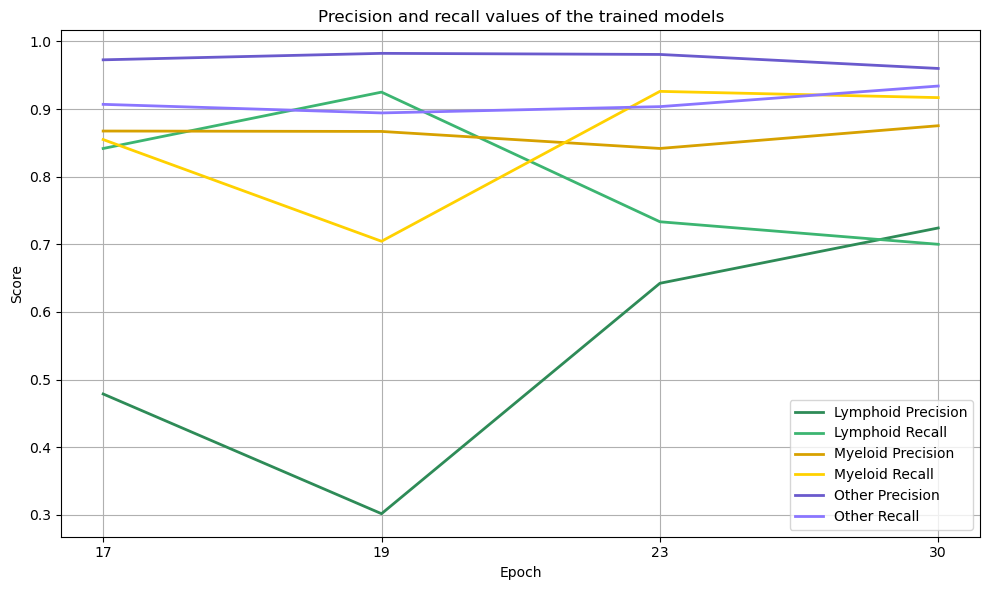

In [30]:
# Plot results

# The columns to plot
selected_cols = ['Lymphoid Precision', 'Lymphoid Recall', 'Myeloid Precision', 'Myeloid Recall', 'Other Precision', 'Other Recall']

# Define base hexcodes for the 3 groups
base_colors = ['#2E8B57','#D7A100','#6A5ACD']


yaxis = [17, 19, 23, 30]
# Helper to lighten/darken a hex color
def adjust_color(hex_color, factor=1.2):
    rgb = mcolors.hex2color(hex_color)
    adjusted_rgb = tuple(min(1, c * factor) for c in rgb)
    return adjusted_rgb
    
# Create pairs of (base, lighter) shades for each group
color_pairs = []
for base in base_colors:
    color_pairs.append([base, adjust_color(base, factor=1.3)])


# Flatten the list to match 6 lines
flat_colors = [color for pair in color_pairs for color in pair]

# Plot
plt.figure(figsize=(10, 6))

for i, col in enumerate(selected_cols):
    plt.plot(results_epochs.index, results_epochs[col], label=col, color=flat_colors[i], linewidth=2)

plt.legend()
plt.title("Precision and recall values of the trained models")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.xticks(ticks= [0, 1, 2, 3], labels=[17, 19, 23, 30])
plt.grid(True)
plt.tight_layout()

#Optional, save the figure
plt.savefig('PrecisionRecallplotALL.png', dpi=500, bbox_inches='tight')

plt.show()

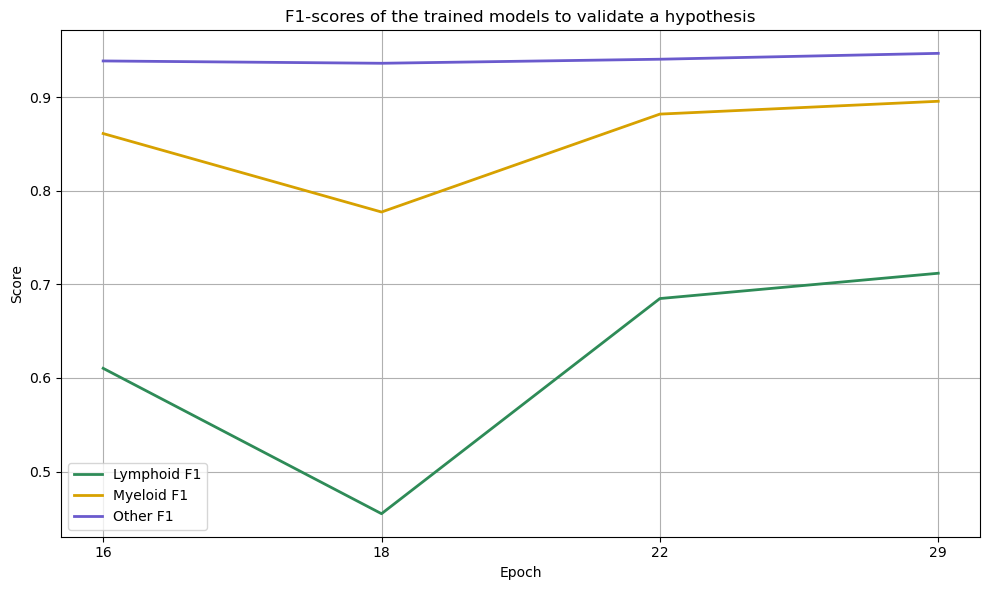

In [31]:
# Plot results

# The columns to plot
selected_cols = ['Lymphoid F1',  'Myeloid F1', 'Other F1']

# Define base hexcodes for the 3 groups
base_colors = ['#2E8B57','#D7A100','#6A5ACD']
epoch_index = [16, 18, 22, 29]

##865C70

# Plot
plt.figure(figsize=(10, 6))

for i, col in enumerate(selected_cols):
    plt.plot(results_epochs.index, results_epochs[col], label=col, color=base_colors[i], linewidth=2)

plt.legend()
plt.title("F1-scores of the trained models to validate a hypothesis")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.xticks(ticks= [0, 1, 2, 3], labels=epoch_index)
plt.grid(True)
plt.tight_layout()

# Define output directory to save image
out_dir  = "DeepHeme_training/Paperimages"           
out_name = "Score across epochs.pdf"
out_path = os.path.join(out_dir, out_name)


#  Save the current figure as a PDF
plt.savefig(
    out_path,
    format="pdf",        
    dpi=300,              
    bbox_inches="tight"   
)

plt.show()

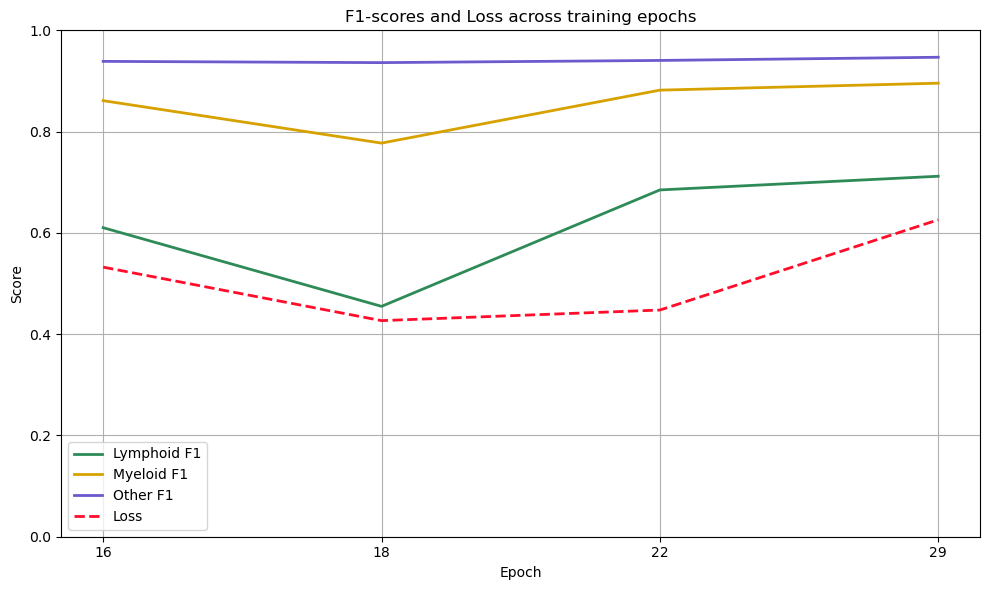

In [32]:
import matplotlib.pyplot as plt
import os

# Data
selected_cols = ['Lymphoid F1', 'Myeloid F1', 'Other F1']
base_colors = ['#2E8B57', '#D7A100', '#6A5ACD']
epoch_index = [16, 18, 22, 29]          # actual epoch numbers
x_positions = [0, 1, 2, 3]              # positions for plotting

# Example: assuming these are precomputed loss values
# loss = [...]  # length = 29
loss_at_epochs = [loss[i] for i in epoch_index]  # extract 4 values
loss_at_epochs = [float(loss) for loss in loss_at_epochs]

# Begin plot
plt.figure(figsize=(10, 6))

# Plot F1 scores for each selected column
for i, col in enumerate(selected_cols):
    plt.plot(x_positions, results_epochs[col], label=col, color=base_colors[i], linewidth=2)

# Plot loss on the same axis
plt.plot(x_positions, loss_at_epochs, label='Loss', color='#FF0D2A',
         linewidth=2, linestyle='--')

# Customize axes and ticks
plt.xticks(ticks=x_positions, labels=epoch_index)
plt.ylim(0, 1)
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("F1-scores and Loss across training epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save
out_dir = "DeepHeme_training/Paperimages"
out_name = "Score vs validation loss across epochs.pdf"
out_path = os.path.join(out_dir, out_name)
plt.savefig(out_path, format="pdf", dpi=300, bbox_inches="tight")

# Show
plt.show()

# Visualise Training loss across epochs in graph

In [5]:
# Copied model output of checkpoint_best_202561710-29
modeloutput = '==> Epoch: 1 Step: 50 LR: 0.001000 Total Loss: 2.4306 Runtime: 4.85 s/50 iters.==> Epoch: 1 Step: 100 LR: 0.001000 Total Loss: 0.5620 Runtime: 3.81 s/50 iters.==> Epoch: 1 Step: 150 LR: 0.001000 Total Loss: 0.5357 Runtime: 3.48 s/50 iters.==> Epoch: 1 Step: 200 LR: 0.001000 Total Loss: 0.5969 Runtime: 4.53 s/50 iters.==> Epoch: 1 Step: 250 LR: 0.001000 Total Loss: 0.8147 Runtime: 4.37 s/50 iters.==> Epoch: 1 Step: 300 LR: 0.001000 Total Loss: 1.0726 Runtime: 3.80 s/50 iters.==> Epoch: 1 Step: 350 LR: 0.001000 Total Loss: 0.7571 Runtime: 4.47 s/50 iters.==> Epoch: 1 Step: 400 LR: 0.001000 Total Loss: 0.8928 Runtime: 4.38 s/50 iters.==> Epoch: 1 Step: 450 LR: 0.001000 Total Loss: 0.7423 Runtime: 4.47 s/50 iters.==> Epoch: 1 Step: 500 LR: 0.001000 Total Loss: 0.6422 Runtime: 4.41 s/50 iters.==> Epoch: 1 Loss 0.742973 .==> Epoch: 2 Step: 550 LR: 0.000997 Total Loss: 0.6732 Runtime: 4.45 s/50 iters.==> Epoch: 2 Step: 600 LR: 0.000997 Total Loss: 0.7642 Runtime: 6.36 s/50 iters.==> Epoch: 2 Step: 650 LR: 0.000997 Total Loss: 0.5208 Runtime: 6.61 s/50 iters.==> Epoch: 2 Step: 700 LR: 0.000997 Total Loss: 0.7889 Runtime: 6.63 s/50 iters.==> Epoch: 2 Step: 750 LR: 0.000997 Total Loss: 0.8854 Runtime: 6.59 s/50 iters.==> Epoch: 2 Step: 800 LR: 0.000997 Total Loss: 0.6908 Runtime: 6.78 s/50 iters.==> Epoch: 2 Step: 850 LR: 0.000997 Total Loss: 0.7152 Runtime: 6.55 s/50 iters.==> Epoch: 2 Step: 900 LR: 0.000997 Total Loss: 0.8002 Runtime: 6.45 s/50 iters.==> Epoch: 2 Step: 950 LR: 0.000997 Total Loss: 0.8680 Runtime: 6.44 s/50 iters.==> Epoch: 2 Step: 1000 LR: 0.000997 Total Loss: 0.3334 Runtime: 6.45 s/50 iters.==> Epoch: 2 Loss 0.610469 .==> Epoch: 3 Step: 1050 LR: 0.000989 Total Loss: 0.5528 Runtime: 2.67 s/50 iters.==> Epoch: 3 Step: 1100 LR: 0.000989 Total Loss: 1.6786 Runtime: 6.59 s/50 iters.==> Epoch: 3 Step: 1150 LR: 0.000989 Total Loss: 0.7394 Runtime: 6.50 s/50 iters.==> Epoch: 3 Step: 1200 LR: 0.000989 Total Loss: 0.5245 Runtime: 6.56 s/50 iters.==> Epoch: 3 Step: 1250 LR: 0.000989 Total Loss: 0.5896 Runtime: 6.40 s/50 iters.==> Epoch: 3 Step: 1300 LR: 0.000989 Total Loss: 0.5833 Runtime: 6.39 s/50 iters.==> Epoch: 3 Step: 1350 LR: 0.000989 Total Loss: 0.7333 Runtime: 6.50 s/50 iters.==> Epoch: 3 Step: 1400 LR: 0.000989 Total Loss: 0.5389 Runtime: 6.43 s/50 iters.==> Epoch: 3 Step: 1450 LR: 0.000989 Total Loss: 0.7810 Runtime: 6.44 s/50 iters.==> Epoch: 3 Step: 1500 LR: 0.000989 Total Loss: 0.5040 Runtime: 6.39 s/50 iters.==> Epoch: 3 Loss 0.645461 .==> Epoch: 4 Step: 1550 LR: 0.000976 Total Loss: 0.7604 Runtime: 0.75 s/50 iters.==> Epoch: 4 Step: 1600 LR: 0.000976 Total Loss: 0.3427 Runtime: 6.23 s/50 iters.==> Epoch: 4 Step: 1650 LR: 0.000976 Total Loss: 0.4791 Runtime: 6.39 s/50 iters.==> Epoch: 4 Step: 1700 LR: 0.000976 Total Loss: 0.4734 Runtime: 6.34 s/50 iters.==> Epoch: 4 Step: 1750 LR: 0.000976 Total Loss: 0.5844 Runtime: 6.42 s/50 iters.==> Epoch: 4 Step: 1800 LR: 0.000976 Total Loss: 0.6598 Runtime: 6.36 s/50 iters.==> Epoch: 4 Step: 1850 LR: 0.000976 Total Loss: 0.6634 Runtime: 6.38 s/50 iters.==> Epoch: 4 Step: 1900 LR: 0.000976 Total Loss: 0.5010 Runtime: 6.42 s/50 iters.==> Epoch: 4 Step: 1950 LR: 0.000976 Total Loss: 0.4644 Runtime: 6.50 s/50 iters.==> Epoch: 4 Step: 2000 LR: 0.000976 Total Loss: 0.5170 Runtime: 6.44 s/50 iters.==> Epoch: 4 Step: 2050 LR: 0.000976 Total Loss: 0.4726 Runtime: 6.43 s/50 iters.==> Epoch: 4 Loss 0.731980 .==> Epoch: 5 Step: 2100 LR: 0.000957 Total Loss: 0.4539 Runtime: 5.16 s/50 iters.==> Epoch: 5 Step: 2150 LR: 0.000957 Total Loss: 0.7016 Runtime: 6.38 s/50 iters.==> Epoch: 5 Step: 2200 LR: 0.000957 Total Loss: 0.4127 Runtime: 6.42 s/50 iters.==> Epoch: 5 Step: 2250 LR: 0.000957 Total Loss: 0.4507 Runtime: 6.39 s/50 iters.==> Epoch: 5 Step: 2300 LR: 0.000957 Total Loss: 0.3552 Runtime: 6.40 s/50 iters.==> Epoch: 5 Step: 2350 LR: 0.000957 Total Loss: 0.6730 Runtime: 6.39 s/50 iters.==> Epoch: 5 Step: 2400 LR: 0.000957 Total Loss: 0.6007 Runtime: 6.61 s/50 iters.==> Epoch: 5 Step: 2450 LR: 0.000957 Total Loss: 0.5124 Runtime: 6.47 s/50 iters.==> Epoch: 5 Step: 2500 LR: 0.000957 Total Loss: 0.4891 Runtime: 6.36 s/50 iters.==> Epoch: 5 Step: 2550 LR: 0.000957 Total Loss: 0.4933 Runtime: 6.37 s/50 iters.==> Epoch: 5 Loss 0.558825 .==> Epoch: 6 Step: 2600 LR: 0.000933 Total Loss: 0.6915 Runtime: 3.19 s/50 iters.==> Epoch: 6 Step: 2650 LR: 0.000933 Total Loss: 0.3555 Runtime: 6.37 s/50 iters.==> Epoch: 6 Step: 2700 LR: 0.000933 Total Loss: 0.3616 Runtime: 6.39 s/50 iters.==> Epoch: 6 Step: 2750 LR: 0.000933 Total Loss: 0.5027 Runtime: 6.41 s/50 iters.==> Epoch: 6 Step: 2800 LR: 0.000933 Total Loss: 0.5202 Runtime: 6.45 s/50 iters.==> Epoch: 6 Step: 2850 LR: 0.000933 Total Loss: 0.8444 Runtime: 6.52 s/50 iters.==> Epoch: 6 Step: 2900 LR: 0.000933 Total Loss: 0.3595 Runtime: 6.41 s/50 iters.==> Epoch: 6 Step: 2950 LR: 0.000933 Total Loss: 0.4364 Runtime: 6.43 s/50 iters.==> Epoch: 6 Step: 3000 LR: 0.000933 Total Loss: 0.5148 Runtime: 6.44 s/50 iters.==> Epoch: 6 Step: 3050 LR: 0.000933 Total Loss: 0.4851 Runtime: 6.40 s/50 iters.==> Epoch: 6 Loss 1.867187 .==> Epoch: 7 Step: 3100 LR: 0.000905 Total Loss: 0.4463 Runtime: 1.36 s/50 iters.==> Epoch: 7 Step: 3150 LR: 0.000905 Total Loss: 0.3325 Runtime: 6.26 s/50 iters.==> Epoch: 7 Step: 3200 LR: 0.000905 Total Loss: 0.5607 Runtime: 6.37 s/50 iters.==> Epoch: 7 Step: 3250 LR: 0.000905 Total Loss: 0.3849 Runtime: 6.42 s/50 iters.==> Epoch: 7 Step: 3300 LR: 0.000905 Total Loss: 0.3289 Runtime: 6.43 s/50 iters.==> Epoch: 7 Step: 3350 LR: 0.000905 Total Loss: 0.4253 Runtime: 6.55 s/50 iters.==> Epoch: 7 Step: 3400 LR: 0.000905 Total Loss: 0.4374 Runtime: 6.43 s/50 iters.==> Epoch: 7 Step: 3450 LR: 0.000905 Total Loss: 0.3487 Runtime: 6.46 s/50 iters.==> Epoch: 7 Step: 3500 LR: 0.000905 Total Loss: 0.3402 Runtime: 6.41 s/50 iters.==> Epoch: 7 Step: 3550 LR: 0.000905 Total Loss: 0.3634 Runtime: 6.45 s/50 iters.==> Epoch: 7 Step: 3600 LR: 0.000905 Total Loss: 0.3687 Runtime: 6.48 s/50 iters.==> Epoch: 7 Loss 0.698478 .==> Epoch: 8 Step: 3650 LR: 0.000872 Total Loss: 0.6018 Runtime: 5.75 s/50 iters.==> Epoch: 8 Step: 3700 LR: 0.000872 Total Loss: 0.4472 Runtime: 6.43 s/50 iters.==> Epoch: 8 Step: 3750 LR: 0.000872 Total Loss: 0.6854 Runtime: 6.37 s/50 iters.==> Epoch: 8 Step: 3800 LR: 0.000872 Total Loss: 0.5456 Runtime: 6.41 s/50 iters.==> Epoch: 8 Step: 3850 LR: 0.000872 Total Loss: 0.4710 Runtime: 6.41 s/50 iters.==> Epoch: 8 Step: 3900 LR: 0.000872 Total Loss: 0.5082 Runtime: 6.33 s/50 iters.==> Epoch: 8 Step: 3950 LR: 0.000872 Total Loss: 0.6483 Runtime: 6.38 s/50 iters.==> Epoch: 8 Step: 4000 LR: 0.000872 Total Loss: 0.2564 Runtime: 6.42 s/50 iters.==> Epoch: 8 Step: 4050 LR: 0.000872 Total Loss: 0.4093 Runtime: 6.42 s/50 iters.==> Epoch: 8 Step: 4100 LR: 0.000872 Total Loss: 0.3037 Runtime: 6.45 s/50 iters.==> Epoch: 8 Loss 0.416726 .==> Epoch: 9 Step: 4150 LR: 0.000835 Total Loss: 0.4434 Runtime: 3.88 s/50 iters.==> Epoch: 9 Step: 4200 LR: 0.000835 Total Loss: 0.3247 Runtime: 6.31 s/50 iters.==> Epoch: 9 Step: 4250 LR: 0.000835 Total Loss: 0.4689 Runtime: 6.40 s/50 iters.==> Epoch: 9 Step: 4300 LR: 0.000835 Total Loss: 0.3678 Runtime: 6.34 s/50 iters.==> Epoch: 9 Step: 4350 LR: 0.000835 Total Loss: 0.6962 Runtime: 6.40 s/50 iters.==> Epoch: 9 Step: 4400 LR: 0.000835 Total Loss: 0.6286 Runtime: 6.39 s/50 iters.==> Epoch: 9 Step: 4450 LR: 0.000835 Total Loss: 0.4703 Runtime: 6.46 s/50 iters.==> Epoch: 9 Step: 4500 LR: 0.000835 Total Loss: 0.4859 Runtime: 6.42 s/50 iters.==> Epoch: 9 Step: 4550 LR: 0.000835 Total Loss: 0.8318 Runtime: 6.44 s/50 iters.==> Epoch: 9 Step: 4600 LR: 0.000835 Total Loss: 0.5035 Runtime: 6.43 s/50 iters.==> Epoch: 9 Loss 0.495804 .==> Epoch: 10 Step: 4650 LR: 0.000794 Total Loss: 0.4378 Runtime: 2.01 s/50 iters.==> Epoch: 10 Step: 4700 LR: 0.000794 Total Loss: 0.6809 Runtime: 6.23 s/50 iters.==> Epoch: 10 Step: 4750 LR: 0.000794 Total Loss: 0.2950 Runtime: 6.43 s/50 iters==> Epoch: 10 Step: 4800 LR: 0.000794 Total Loss: 0.7068 Runtime: 6.36 s/50 iters.==> Epoch: 10 Step: 4850 LR: 0.000794 Total Loss: 0.3860 Runtime: 6.44 s/50 iters.==> Epoch: 10 Step: 4900 LR: 0.000794 Total Loss: 0.3489 Runtime: 6.38 s/50 iters.==> Epoch: 10 Step: 4950 LR: 0.000794 Total Loss: 0.4131 Runtime: 6.38 s/50 iters.==> Epoch: 10 Step: 5000 LR: 0.000794 Total Loss: 0.7516 Runtime: 6.38 s/50 iters.==> Epoch: 10 Step: 5050 LR: 0.000794 Total Loss: 0.3862 Runtime: 6.39 s/50 iters.==> Epoch: 10 Step: 5100 LR: 0.000794 Total Loss: 0.3562 Runtime: 6.50 s/50 iters.==> Epoch: 10 Step: 5150 LR: 0.000794 Total Loss: 0.4292 Runtime: 6.37 s/50 iters.==> Epoch: 10 Loss 0.408352 .==> Epoch: 11 Step: 5200 LR: 0.000750 Total Loss: 0.5989 Runtime: 6.32 s/50 iters.==> Epoch: 11 Step: 5250 LR: 0.000750 Total Loss: 0.1985 Runtime: 6.44 s/50 iters.==> Epoch: 11 Step: 5300 LR: 0.000750 Total Loss: 0.3267 Runtime: 6.43 s/50 iters.==> Epoch: 11 Step: 5350 LR: 0.000750 Total Loss: 0.3199 Runtime: 6.34 s/50 iters.==> Epoch: 11 Step: 5400 LR: 0.000750 Total Loss: 0.3288 Runtime: 6.36 s/50 iters.==> Epoch: 11 Step: 5450 LR: 0.000750 Total Loss: 0.3609 Runtime: 6.53 s/50 iters.==> Epoch: 11 Step: 5500 LR: 0.000750 Total Loss: 0.5753 Runtime: 6.47 s/50 iters.==> Epoch: 11 Step: 5550 LR: 0.000750 Total Loss: 0.1949 Runtime: 6.40 s/50 iters.==> Epoch: 11 Step: 5600 LR: 0.000750 Total Loss: 0.9199 Runtime: 6.46 s/50 iters.==> Epoch: 11 Step: 5650 LR: 0.000750 Total Loss: 0.3849 Runtime: 6.39 s/50 iters.==> Epoch: 11 Loss 0.572201 .==> Epoch: 12 Step: 5700 LR: 0.000703 Total Loss: 0.2856 Runtime: 4.54 s/50 iters.==> Epoch: 12 Step: 5750 LR: 0.000703 Total Loss: 0.3163 Runtime: 6.40 s/50 iters.==> Epoch: 12 Step: 5800 LR: 0.000703 Total Loss: 0.9410 Runtime: 6.33 s/50 iters.==> Epoch: 12 Step: 5850 LR: 0.000703 Total Loss: 0.2441 Runtime: 6.38 s/50 iters.==> Epoch: 12 Step: 5900 LR: 0.000703 Total Loss: 0.4459 Runtime: 6.38 s/50 iters.==> Epoch: 12 Step: 5950 LR: 0.000703 Total Loss: 0.5247 Runtime: 6.33 s/50 iters.==> Epoch: 12 Step: 6000 LR: 0.000703 Total Loss: 0.4213 Runtime: 6.37 s/50 iters.==> Epoch: 12 Step: 6050 LR: 0.000703 Total Loss: 0.3453 Runtime: 6.34 s/50 iters.==> Epoch: 12 Step: 6100 LR: 0.000703 Total Loss: 0.2558 Runtime: 6.36 s/50 iters.==> Epoch: 12 Step: 6150 LR: 0.000703 Total Loss: 0.3596 Runtime: 6.37 s/50 iters.==> Epoch: 12 Loss 0.522469 .==> Epoch: 13 Step: 6200 LR: 0.000655 Total Loss: 0.3299 Runtime: 2.51 s/50 iters.==> Epoch: 13 Step: 6250 LR: 0.000655 Total Loss: 0.4250 Runtime: 6.30 s/50 iters.==> Epoch: 13 Step: 6300 LR: 0.000655 Total Loss: 0.4394 Runtime: 6.58 s/50 iters.==> Epoch: 13 Step: 6350 LR: 0.000655 Total Loss: 0.4854 Runtime: 6.50 s/50 iters.==> Epoch: 13 Step: 6400 LR: 0.000655 Total Loss: 0.7245 Runtime: 6.42 s/50 iters.==> Epoch: 13 Step: 6450 LR: 0.000655 Total Loss: 0.1254 Runtime: 6.62 s/50 iters.==> Epoch: 13 Step: 6500 LR: 0.000655 Total Loss: 0.1950 Runtime: 6.42 s/50 iters.==> Epoch: 13 Step: 6550 LR: 0.000655 Total Loss: 0.2692 Runtime: 6.44 s/50 iters.==> Epoch: 13 Step: 6600 LR: 0.000655 Total Loss: 0.2243 Runtime: 6.41 s/50 iters.==> Epoch: 13 Step: 6650 LR: 0.000655 Total Loss: 0.1107 Runtime: 6.40 s/50 iters.==> Epoch: 13 Loss 0.349996 .==> Epoch: 14 Step: 6700 LR: 0.000604 Total Loss: 0.5023 Runtime: 0.80 s/50 iters.==> Epoch: 14 Step: 6750 LR: 0.000604 Total Loss: 0.2167 Runtime: 6.14 s/50 iters.==> Epoch: 14 Step: 6800 LR: 0.000604 Total Loss: 0.7253 Runtime: 6.39 s/50 iters.==> Epoch: 14 Step: 6850 LR: 0.000604 Total Loss: 0.2606 Runtime: 6.47 s/50 iters.==> Epoch: 14 Step: 6900 LR: 0.000604 Total Loss: 0.9136 Runtime: 6.72 s/50 iters.==> Epoch: 14 Step: 6950 LR: 0.000604 Total Loss: 0.2155 Runtime: 6.57 s/50 iters.==> Epoch: 14 Step: 7000 LR: 0.000604 Total Loss: 0.4384 Runtime: 6.43 s/50 iters.==> Epoch: 14 Step: 7050 LR: 0.000604 Total Loss: 0.3015 Runtime: 6.41 s/50 iters.==> Epoch: 14 Step: 7100 LR: 0.000604 Total Loss: 0.2445 Runtime: 6.45 s/50 iters.==> Epoch: 14 Step: 7150 LR: 0.000604 Total Loss: 0.6291 Runtime: 6.40 s/50 iters.==> Epoch: 14 Step: 7200 LR: 0.000604 Total Loss: 0.4583 Runtime: 6.41 s/50 iters.==> Epoch: 14 Loss 0.347176 .==> Epoch: 15 Step: 7250 LR: 0.000552 Total Loss: 0.3289 Runtime: 5.02 s/50 iters.==> Epoch: 15 Step: 7300 LR: 0.000552 Total Loss: 0.2507 Runtime: 6.48 s/50 iters.==> Epoch: 15 Step: 7350 LR: 0.000552 Total Loss: 0.1573 Runtime: 6.47 s/50 iters.==> Epoch: 15 Step: 7400 LR: 0.000552 Total Loss: 0.1848 Runtime: 6.67 s/50 iters.==> Epoch: 15 Step: 7450 LR: 0.000552 Total Loss: 0.6359 Runtime: 6.68 s/50 iters.==> Epoch: 15 Step: 7500 LR: 0.000552 Total Loss: 0.4020 Runtime: 6.60 s/50 iters.==> Epoch: 15 Step: 7550 LR: 0.000552 Total Loss: 0.4711 Runtime: 6.51 s/50 iters.==> Epoch: 15 Step: 7600 LR: 0.000552 Total Loss: 0.2483 Runtime: 6.49 s/50 iters.==> Epoch: 15 Step: 7650 LR: 0.000552 Total Loss: 0.1362 Runtime: 6.46 s/50 iters.==> Epoch: 15 Step: 7700 LR: 0.000552 Total Loss: 0.2290 Runtime: 6.50 s/50 iters.==> Epoch: 15 Loss 0.488825 .==> Epoch: 16 Step: 7750 LR: 0.000500 Total Loss: 0.3836 Runtime: 3.17 s/50 iters.==> Epoch: 16 Step: 7800 LR: 0.000500 Total Loss: 0.2010 Runtime: 6.33 s/50 iters.==> Epoch: 16 Step: 7850 LR: 0.000500 Total Loss: 0.5165 Runtime: 6.79 s/50 iters.==> Epoch: 16 Step: 7900 LR: 0.000500 Total Loss: 0.4180 Runtime: 6.53 s/50 iters.==> Epoch: 16 Step: 7950 LR: 0.000500 Total Loss: 0.4245 Runtime: 6.44 s/50 iters.==> Epoch: 16 Step: 8000 LR: 0.000500 Total Loss: 0.1416 Runtime: 6.42 s/50 iters.==> Epoch: 16 Step: 8050 LR: 0.000500 Total Loss: 0.1800 Runtime: 6.47 s/50 iters.==> Epoch: 16 Step: 8100 LR: 0.000500 Total Loss: 0.1369 Runtime: 6.62 s/50 iters.==> Epoch: 16 Step: 8150 LR: 0.000500 Total Loss: 0.2215 Runtime: 6.40 s/50 iters.==> Epoch: 16 Step: 8200 LR: 0.000500 Total Loss: 0.1534 Runtime: 6.39 s/50 iters.==> Epoch: 16 Loss 0.477392 .==> Epoch: 17 Step: 8250 LR: 0.000448 Total Loss: 0.2646 Runtime: 1.37 s/50 iters.==> Epoch: 17 Step: 8300 LR: 0.000448 Total Loss: 0.2659 Runtime: 6.13 s/50 iters.==> Epoch: 17 Step: 8350 LR: 0.000448 Total Loss: 0.3690 Runtime: 6.36 s/50 iters.==> Epoch: 17 Step: 8400 LR: 0.000448 Total Loss: 0.2536 Runtime: 6.39 s/50 iters.==> Epoch: 17 Step: 8450 LR: 0.000448 Total Loss: 0.3074 Runtime: 6.35 s/50 iters.==> Epoch: 17 Step: 8500 LR: 0.000448 Total Loss: 0.2522 Runtime: 6.34 s/50 iters.==> Epoch: 17 Step: 8550 LR: 0.000448 Total Loss: 0.3201 Runtime: 6.31 s/50 iters.==> Epoch: 17 Step: 8600 LR: 0.000448 Total Loss: 0.0495 Runtime: 6.34 s/50 iters.==> Epoch: 17 Step: 8650 LR: 0.000448 Total Loss: 0.3658 Runtime: 6.33 s/50 iters.==> Epoch: 17 Step: 8700 LR: 0.000448 Total Loss: 0.4364 Runtime: 6.47 s/50 iters.==> Epoch: 17 Step: 8750 LR: 0.000448 Total Loss: 0.5769 Runtime: 6.44 s/50 iters.==> Epoch: 17 Loss 0.532370 .==> Epoch: 18 Step: 8800 LR: 0.000396 Total Loss: 0.2065 Runtime: 5.73 s/50 iters.==> Epoch: 18 Step: 8850 LR: 0.000396 Total Loss: 0.3103 Runtime: 6.35 s/50 iters.==> Epoch: 18 Step: 8900 LR: 0.000396 Total Loss: 0.1749 Runtime: 6.41 s/50 iters.==> Epoch: 18 Step: 8950 LR: 0.000396 Total Loss: 0.1438 Runtime: 6.41 s/50 iters.==> Epoch: 18 Step: 9000 LR: 0.000396 Total Loss: 0.1626 Runtime: 6.42 s/50 iters.==> Epoch: 18 Step: 9050 LR: 0.000396 Total Loss: 0.1950 Runtime: 6.38 s/50 iters.==> Epoch: 18 Step: 9100 LR: 0.000396 Total Loss: 0.5891 Runtime: 6.39 s/50 iters.==> Epoch: 18 Step: 9150 LR: 0.000396 Total Loss: 0.1563 Runtime: 6.30 s/50 iters.==> Epoch: 18 Step: 9200 LR: 0.000396 Total Loss: 0.1473 Runtime: 6.36 s/50 iters.==> Epoch: 18 Step: 9250 LR: 0.000396 Total Loss: 0.0655 Runtime: 6.33 s/50 iters.==> Epoch: 18 Loss 0.329441 .==> Epoch: 19 Step: 9300 LR: 0.000345 Total Loss: 0.1390 Runtime: 3.75 s/50 iters.==> Epoch: 19 Step: 9350 LR: 0.000345 Total Loss: 0.4171 Runtime: 6.16 s/50 iters.==> Epoch: 19 Step: 9400 LR: 0.000345 Total Loss: 0.3103 Runtime: 6.33 s/50 iters.==> Epoch: 19 Step: 9450 LR: 0.000345 Total Loss: 0.4670 Runtime: 6.45 s/50 iters.==> Epoch: 19 Step: 9500 LR: 0.000345 Total Loss: 0.3224 Runtime: 6.34 s/50 iters.==> Epoch: 19 Step: 9550 LR: 0.000345 Total Loss: 0.1541 Runtime: 6.40 s/50 iters.==> Epoch: 19 Step: 9600 LR: 0.000345 Total Loss: 0.2456 Runtime: 6.31 s/50 iters.==> Epoch: 19 Step: 9650 LR: 0.000345 Total Loss: 0.2777 Runtime: 6.33 s/50 iters.==> Epoch: 19 Step: 9700 LR: 0.000345 Total Loss: 0.0928 Runtime: 6.36 s/50 iters.==> Epoch: 19 Step: 9750 LR: 0.000345 Total Loss: 0.2715 Runtime: 6.38 s/50 iters.==> Epoch: 19 Loss 0.426716 .==> Epoch: 20 Step: 9800 LR: 0.000297 Total Loss: 0.2071 Runtime: 1.99 s/50 iters.==> Epoch: 20 Step: 9850 LR: 0.000297 Total Loss: 0.1925 Runtime: 6.22 s/50 iters.==> Epoch: 20 Step: 9900 LR: 0.000297 Total Loss: 0.1705 Runtime: 6.43 s/50 iters.==> Epoch: 20 Step: 9950 LR: 0.000297 Total Loss: 0.0717 Runtime: 6.36 s/50 iters.==> Epoch: 20 Step: 10000 LR: 0.000297 Total Loss: 0.1343 Runtime: 6.35 s/50 iters.==> Epoch: 20 Step: 10050 LR: 0.000297 Total Loss: 0.1631 Runtime: 6.39 s/50 iters.==> Epoch: 20 Step: 10100 LR: 0.000297 Total Loss: 0.1790 Runtime: 6.68 s/50 iters.==> Epoch: 20 Step: 10150 LR: 0.000297 Total Loss: 0.1877 Runtime: 6.62 s/50 iters.==> Epoch: 20 Step: 10200 LR: 0.000297 Total Loss: 0.2532 Runtime: 6.55 s/50 iters.==> Epoch: 20 Step: 10250 LR: 0.000297 Total Loss: 0.3840 Runtime: 6.39 s/50 iters.==> Epoch: 20 Step: 10300 LR: 0.000297 Total Loss: 0.2597 Runtime: 6.42 s/50 iters.==> Epoch: 20 Loss 0.405684 .==> Epoch: 21 Step: 10350 LR: 0.000250 Total Loss: 0.3951 Runtime: 6.51 s/50 iters.==> Epoch: 21 Step: 10400 LR: 0.000250 Total Loss: 0.0933 Runtime: 6.44 s/50 iters.==> Epoch: 21 Step: 10450 LR: 0.000250 Total Loss: 0.1339 Runtime: 6.46 s/50 iters.==> Epoch: 21 Step: 10500 LR: 0.000250 Total Loss: 0.1420 Runtime: 6.33 s/50 iters.==> Epoch: 21 Step: 10550 LR: 0.000250 Total Loss: 0.1001 Runtime: 6.48 s/50 iters.==> Epoch: 21 Step: 10600 LR: 0.000250 Total Loss: 0.2755 Runtime: 6.46 s/50 iters.==> Epoch: 21 Step: 10650 LR: 0.000250 Total Loss: 0.1055 Runtime: 6.44 s/50 iters.==> Epoch: 21 Step: 10700 LR: 0.000250 Total Loss: 0.0498 Runtime: 6.47 s/50 iters.==> Epoch: 21 Step: 10750 LR: 0.000250 Total Loss: 0.0677 Runtime: 6.36 s/50 iters.==> Epoch: 21 Step: 10800 LR: 0.000250 Total Loss: 0.1245 Runtime: 6.50 s/50 iters.==> Epoch: 21 Loss 0.450108 .==> Epoch: 22 Step: 10850 LR: 0.000206 Total Loss: 0.2053 Runtime: 4.45 s/50 iters.==> Epoch: 22 Step: 10900 LR: 0.000206 Total Loss: 0.1037 Runtime: 6.11 s/50 iters.==> Epoch: 22 Step: 10950 LR: 0.000206 Total Loss: 0.0557 Runtime: 6.23 s/50 iters.==> Epoch: 22 Step: 11000 LR: 0.000206 Total Loss: 0.4218 Runtime: 6.28 s/50 iters.==> Epoch: 22 Step: 11050 LR: 0.000206 Total Loss: 0.1222 Runtime: 6.36 s/50 iters.==> Epoch: 22 Step: 11100 LR: 0.000206 Total Loss: 0.0723 Runtime: 6.31 s/50 iters.==> Epoch: 22 Step: 11150 LR: 0.000206 Total Loss: 0.1895 Runtime: 6.30 s/50 iters.==> Epoch: 22 Step: 11200 LR: 0.000206 Total Loss: 0.0196 Runtime: 6.33 s/50 iters.==> Epoch: 22 Step: 11250 LR: 0.000206 Total Loss: 0.0972 Runtime: 6.27 s/50 iters.==> Epoch: 22 Step: 11300 LR: 0.000206 Total Loss: 0.1313 Runtime: 6.25 s/50 iters.==> Epoch: 22 Loss 0.446454 .==> Epoch: 23 Step: 11350 LR: 0.000165 Total Loss: 0.1366 Runtime: 2.58 s/50 iters.==> Epoch: 23 Step: 11400 LR: 0.000165 Total Loss: 0.1144 Runtime: 6.25 s/50 iters.==> Epoch: 23 Step: 11450 LR: 0.000165 Total Loss: 0.2978 Runtime: 6.22 s/50 iters.==> Epoch: 23 Step: 11500 LR: 0.000165 Total Loss: 0.0513 Runtime: 6.19 s/50 iters.==> Epoch: 23 Step: 11550 LR: 0.000165 Total Loss: 0.1206 Runtime: 6.33 s/50 iters.==> Epoch: 23 Step: 11600 LR: 0.000165 Total Loss: 0.2599 Runtime: 6.39 s/50 iters.==> Epoch: 23 Step: 11650 LR: 0.000165 Total Loss: 0.0202 Runtime: 6.78 s/50 iters.==> Epoch: 23 Step: 11700 LR: 0.000165 Total Loss: 0.0295 Runtime: 6.47 s/50 iters.==> Epoch: 23 Step: 11750 LR: 0.000165 Total Loss: 0.0242 Runtime: 6.32 s/50 iters.==> Epoch: 23 Step: 11800 LR: 0.000165 Total Loss: 0.1357 Runtime: 6.28 s/50 iters.==> Epoch: 23 Loss 0.447652 .==> Epoch: 24 Step: 11850 LR: 0.000128 Total Loss: 0.0563 Runtime: 0.78 s/50 iters.==> Epoch: 24 Step: 11900 LR: 0.000128 Total Loss: 0.1115 Runtime: 6.16 s/50 iters.==> Epoch: 24 Step: 11950 LR: 0.000128 Total Loss: 0.1049 Runtime: 6.45 s/50 iters.==> Epoch: 24 Step: 12000 LR: 0.000128 Total Loss: 0.3163 Runtime: 6.33 s/50 iters.==> Epoch: 24 Step: 12050 LR: 0.000128 Total Loss: 0.1279 Runtime: 6.33 s/50 iters.==> Epoch: 24 Step: 12100 LR: 0.000128 Total Loss: 0.0620 Runtime: 6.57 s/50 iters.==> Epoch: 24 Step: 12150 LR: 0.000128 Total Loss: 0.0607 Runtime: 6.64 s/50 iters.==> Epoch: 24 Step: 12200 LR: 0.000128 Total Loss: 0.1020 Runtime: 6.56 s/50 iters.==> Epoch: 24 Step: 12250 LR: 0.000128 Total Loss: 0.1164 Runtime: 6.72 s/50 iters.==> Epoch: 24 Step: 12300 LR: 0.000128 Total Loss: 0.5751 Runtime: 6.76 s/50 iters.==> Epoch: 24 Step: 12350 LR: 0.000128 Total Loss: 0.0952 Runtime: 6.40 s/50 iters.==> Epoch: 24 Loss 0.488964 .==> Epoch: 25 Step: 12400 LR: 0.000095 Total Loss: 0.0421 Runtime: 5.05 s/50 iters.==> Epoch: 25 Step: 12450 LR: 0.000095 Total Loss: 0.0836 Runtime: 6.49 s/50 iters.==> Epoch: 25 Step: 12500 LR: 0.000095 Total Loss: 0.0672 Runtime: 6.46 s/50 iters.==> Epoch: 25 Step: 12550 LR: 0.000095 Total Loss: 0.1328 Runtime: 6.73 s/50 iters.==> Epoch: 25 Step: 12600 LR: 0.000095 Total Loss: 0.1889 Runtime: 6.74 s/50 iters.==> Epoch: 25 Step: 12650 LR: 0.000095 Total Loss: 0.1859 Runtime: 6.62 s/50 iters.==> Epoch: 25 Step: 12700 LR: 0.000095 Total Loss: 0.2033 Runtime: 6.67 s/50 iters.==> Epoch: 25 Step: 12750 LR: 0.000095 Total Loss: 0.1115 Runtime: 6.59 s/50 iters.==> Epoch: 25 Step: 12800 LR: 0.000095 Total Loss: 0.1642 Runtime: 6.67 s/50 iters.==> Epoch: 25 Step: 12850 LR: 0.000095 Total Loss: 0.3618 Runtime: 6.55 s/50 iters.==> Epoch: 25 Loss 0.499182 .==> Epoch: 26 Step: 12900 LR: 0.000067 Total Loss: 0.1119 Runtime: 3.37 s/50 iters.==> Epoch: 26 Step: 12950 LR: 0.000067 Total Loss: 0.0676 Runtime: 6.19 s/50 iters.==> Epoch: 26 Step: 13000 LR: 0.000067 Total Loss: 0.1872 Runtime: 6.36 s/50 iters.==> Epoch: 26 Step: 13050 LR: 0.000067 Total Loss: 0.0826 Runtime: 6.39 s/50 iters.==> Epoch: 26 Step: 13100 LR: 0.000067 Total Loss: 0.0592 Runtime: 6.36 s/50 iters.==> Epoch: 26 Step: 13150 LR: 0.000067 Total Loss: 0.0974 Runtime: 6.38 s/50 iters.==> Epoch: 26 Step: 13200 LR: 0.000067 Total Loss: 0.0541 Runtime: 6.52 s/50 iters.==> Epoch: 26 Step: 13250 LR: 0.000067 Total Loss: 0.0983 Runtime: 6.59 s/50 iters.==> Epoch: 26 Step: 13300 LR: 0.000067 Total Loss: 0.1278 Runtime: 6.44 s/50 iters.==> Epoch: 26 Step: 13350 LR: 0.000067 Total Loss: 0.0672 Runtime: 6.50 s/50 iters.==> Epoch: 26 Loss 0.535916 .==> Epoch: 27 Step: 13400 LR: 0.000043 Total Loss: 0.0625 Runtime: 1.39 s/50 iters.==> Epoch: 27 Step: 13450 LR: 0.000043 Total Loss: 0.2435 Runtime: 6.38 s/50 iters.==> Epoch: 27 Step: 13500 LR: 0.000043 Total Loss: 0.0783 Runtime: 6.46 s/50 iters.==> Epoch: 27 Step: 13550 LR: 0.000043 Total Loss: 0.0606 Runtime: 6.42 s/50 iters.==> Epoch: 27 Step: 13600 LR: 0.000043 Total Loss: 0.0545 Runtime: 6.52 s/50 iters.==> Epoch: 27 Step: 13650 LR: 0.000043 Total Loss: 0.0375 Runtime: 6.49 s/50 iters.==> Epoch: 27 Step: 13700 LR: 0.000043 Total Loss: 0.0375 Runtime: 6.48 s/50 iters.==> Epoch: 27 Step: 13750 LR: 0.000043 Total Loss: 0.0624 Runtime: 6.82 s/50 iters.==> Epoch: 27 Step: 13800 LR: 0.000043 Total Loss: 0.0293 Runtime: 6.65 s/50 iters.==> Epoch: 27 Step: 13850 LR: 0.000043 Total Loss: 0.0937 Runtime: 6.43 s/50 iters.==> Epoch: 27 Step: 13900 LR: 0.000043 Total Loss: 0.0663 Runtime: 6.44 s/50 iters.==> Epoch: 27 Loss 0.614931 .==> Epoch: 28 Step: 13950 LR: 0.000024 Total Loss: 0.0992 Runtime: 5.99 s/50 iters.==> Epoch: 28 Step: 14000 LR: 0.000024 Total Loss: 0.0585 Runtime: 6.71 s/50 iters.==> Epoch: 28 Step: 14050 LR: 0.000024 Total Loss: 0.0340 Runtime: 6.35 s/50 iters.==> Epoch: 28 Step: 14100 LR: 0.000024 Total Loss: 0.0271 Runtime: 7.11 s/50 iters.==> Epoch: 28 Step: 14150 LR: 0.000024 Total Loss: 0.0853 Runtime: 6.61 s/50 iters.==> Epoch: 28 Step: 14200 LR: 0.000024 Total Loss: 0.1434 Runtime: 6.45 s/50 iters.==> Epoch: 28 Step: 14250 LR: 0.000024 Total Loss: 0.0506 Runtime: 6.45 s/50 iters.==> Epoch: 28 Step: 14300 LR: 0.000024 Total Loss: 0.0768 Runtime: 6.40 s/50 iters.==> Epoch: 28 Step: 14350 LR: 0.000024 Total Loss: 0.1986 Runtime: 6.74 s/50 iters.==> Epoch: 28 Step: 14400 LR: 0.000024 Total Loss: 0.0495 Runtime: 6.80 s/50 iters.==> Epoch: 28 Loss 0.667828 .==> Epoch: 29 Step: 14450 LR: 0.000011 Total Loss: 0.0482 Runtime: 3.86 s/50 iters.==> Epoch: 29 Step: 14500 LR: 0.000011 Total Loss: 0.1034 Runtime: 6.55 s/50 iters.==> Epoch: 29 Step: 14550 LR: 0.000011 Total Loss: 0.0604 Runtime: 6.75 s/50 iters.==> Epoch: 29 Step: 14600 LR: 0.000011 Total Loss: 0.1611 Runtime: 6.65 s/50 iters.==> Epoch: 29 Step: 14650 LR: 0.000011 Total Loss: 0.1701 Runtime: 6.59 s/50 iters.==> Epoch: 29 Step: 14700 LR: 0.000011 Total Loss: 0.1437 Runtime: 6.53 s/50 iters.==> Epoch: 29 Step: 14750 LR: 0.000011 Total Loss: 0.0201 Runtime: 6.75 s/50 iters.==> Epoch: 29 Step: 14800 LR: 0.000011 Total Loss: 0.0828 Runtime: 6.50 s/50 iters.==> Epoch: 29 Step: 14850 LR: 0.000011 Total Loss: 0.0766 Runtime: 6.55 s/50 iters.==> Epoch: 29 Step: 14900 LR: 0.000011 Total Loss: 0.0461 Runtime: 6.76 s/50 iters.==> Epoch: 29 Loss 0.614756 .==> Epoch: 30 Step: 14950 LR: 0.000003 Total Loss: 0.1924 Runtime: 1.92 s/50 iters.==> Epoch: 30 Step: 15000 LR: 0.000003 Total Loss: 0.1743 Runtime: 6.36 s/50 iters.==> Epoch: 30 Step: 15050 LR: 0.000003 Total Loss: 0.0978 Runtime: 6.61 s/50 iters.==> Epoch: 30 Step: 15100 LR: 0.000003 Total Loss: 0.1525 Runtime: 6.50 s/50 iters.==> Epoch: 30 Step: 15150 LR: 0.000003 Total Loss: 0.0609 Runtime: 6.60 s/50 iters.==> Epoch: 30 Step: 15200 LR: 0.000003 Total Loss: 0.0154 Runtime: 6.56 s/50 iters.==> Epoch: 30 Step: 15250 LR: 0.000003 Total Loss: 0.1266 Runtime: 6.45 s/50 iters.==> Epoch: 30 Step: 15300 LR: 0.000003 Total Loss: 0.0552 Runtime: 6.46 s/50 iters.==> Epoch: 30 Step: 15350 LR: 0.000003 Total Loss: 0.1130 Runtime: 6.49 s/50 iters.==> Epoch: 30 Step: 15400 LR: 0.000003 Total Loss: 0.0395 Runtime: 6.47 s/50 iters.==> Epoch: 30 Step: 15450 LR: 0.000003 Total Loss: 0.0799 Runtime: 6.46 s/50 iters.==> Epoch: 30 Loss 0.625827 .==> Runtime: 42.13 minutes.'

In [6]:
loss_train = []
loss_val = []
lr = []

# separate the 30 epochs
lst = modeloutput.split(' .')

for i in range(len(lst)-1):
    loss_train.append(lst[i].split('Loss')[-2].split(' Runtime')[0].split(': ')[1])
    loss_val.append(lst[i].split('Loss ')[1])
    lr.append(lst[i].split('LR: ')[1].split(' ')[0])

In [13]:
lst[0].split('Loss')[-2].split(' Runtime')[0].split(': ')[1]

'0.6422'

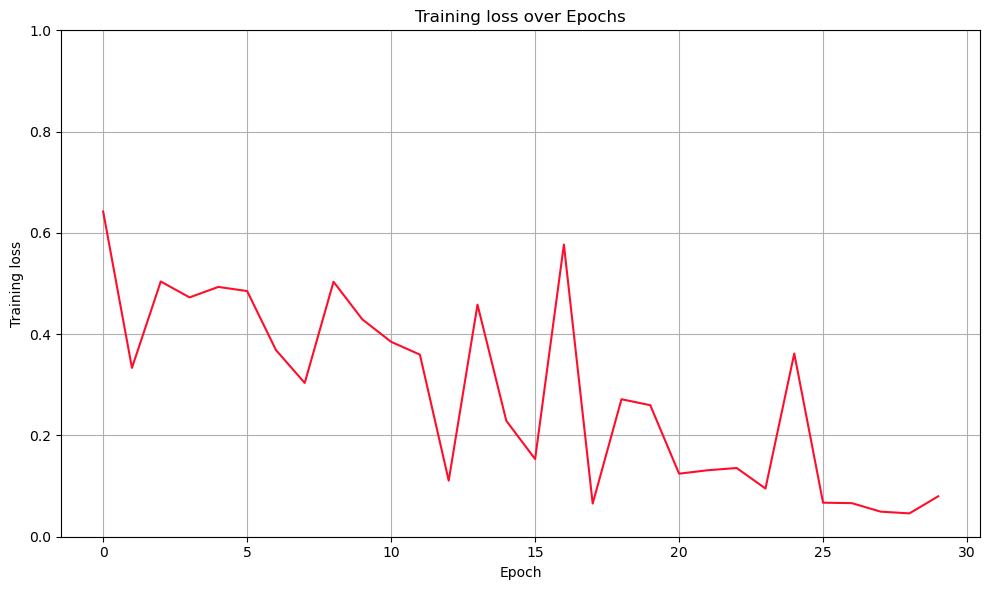

In [26]:
# Convert strings to floats
float_values = [float(val) for val in loss_train]

# Generate epoch numbers (0 through 29)
epochs = list(range(len(float_values)))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs, float_values, color='#FF0D2a')
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.ylim(0,1)
plt.title('Training loss over Epochs')
plt.grid(True)
plt.tight_layout()

# Define output directory to save image
out_dir  = "DeepHeme_training/Paperimages"           
out_name = "Training loss over epochs.pdf"
out_path = os.path.join(out_dir, out_name)


#  Save the current figure as a PDF
plt.savefig(
    out_path,
    format="pdf",        
    dpi=300,              
    bbox_inches="tight"   
)

plt.show()


# Visualize various attempted backgrounds

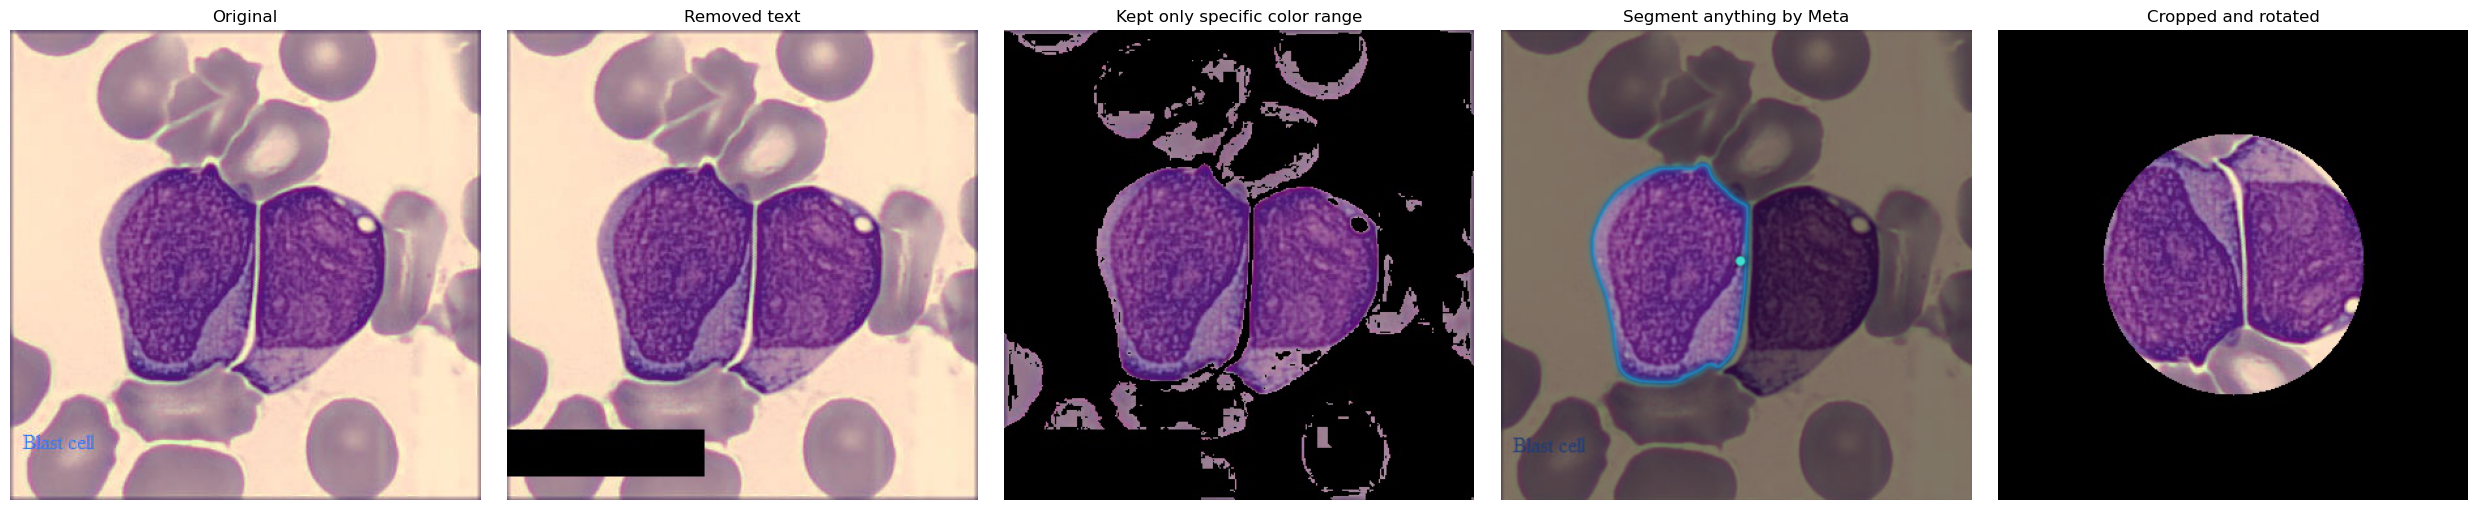

In [47]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

filepaths = ['DeepHeme_training/Datasets/trainingset/AML___240219002635_1_BL_19.jpg', 'DeepHeme_training/Datasets/notextimages/AML___240219002635_1_BL_19.jpg', 'DeepHeme_training/Datasets/segmentedimages/AML___240219002635_1_BL_19.jpg', 'DeepHeme_training/SAM example.png', 'DeepHeme_training/Datasets/croppedimages/AML___240219002635_1_BL_19.jpg']
titles = ['Original', 'Removed text', 'Kept only specific color range', 'Segment anything by Meta', 'Cropped and rotated']

# Number of images
n_images = len(filepaths)

# Create a figure with subplots
fig, axes = plt.subplots(1, n_images, figsize=(5 * n_images, 5))

# If only one image, axes is not iterable
if n_images == 1:
    axes = [axes]

# Plot each image
count = 0
for ax, path in zip(axes, filepaths):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.axis('off')  # Hide axis
    ax.set_title(titles[count])  # Optional: set filename as title
    count+=1

plt.tight_layout()
plt.show()
